# **Rent Analysis in Seoul** 

## **Introduction**

The aim of this analysis is to find the key about why the rentals in South Korea's rental market have been increasing rapidly in recent years, and to identify the factors that contribute to this trend.

This analysis will focus in datasets extracted form Seoul Open Data Plaza (https://data.seoul.go.kr/#), and will include data on rental prices, housing types, and other relevant factors.

The datasets used in this analysis are:
- Seoul Real Estate Jeonse and Monthly Rent Price Information (https://data.seoul.go.kr/dataList/OA-21276/S/1/datasetView.do)

I take the datasets from the years 2022, 2023, 2024 and 2025 , which are the most recent years available in the dataset. All the datasets where merged into one dataset for the analysis and take randomly 400000 rows for the analysis.

The information about the columns from the dataset are the next:
<center>

|Column Name|Column Description|Notes|
|:---|:-------|:-------|
|`registration_year`|Year the contract was registered (file year).|Not the contract year; use `contract_date` for that. A few rows are 2021.|
|`district_code`|Code of the Seoul district (gu).|5 digits. See Lookup_Dongs.|
|`district_name`|District name in English.|Recovered from `district_code` (25 districts).|
|`legal_dong_code`|Code of the legal neighborhood (dong) within the district.|Only unique together with `district_code`.|
|`legal_dong_name`|Neighborhood name, romanized.|Automatic romanization; Korean original in Lookup_Dongs. Blank for a few unmapped codes.|
|`lot_type_code`|Type of lot number: 1, 2 or 3.|Blank for detached / multi-household houses (no lot number in source).|
|`lot_type`|Land lot / Mountain lot / Block lot.|From `lot_type_code`.|
|`main_lot_number`|Main lot number (jibun) of the address.||
|`sub_lot_number`|Sub lot number (jibun) of the address.|0 = none.|
|`floor`|Floor of the unit.|Negative = basement. Blank if not reported.|
|`contract_date`|Date the contract was signed.|Format yyyy-mm-dd.|
|`lease_type`|Jeonse (deposit only) or Monthly rent.|2023: original value. Other years: inferred (monthly rent = 0 -> Jeonse); matches the original in 99.96% of 2023 rows.|
|`leased_area_sqm`|Leased area in square meters (m2).||
|`deposit_10k_krw`|Deposit, in 10,000 KRW.|Example: 16000 = 160,000,000 KRW.|
|`monthly_rent_10k_krw`|Monthly rent, in 10,000 KRW.|0 for Jeonse.|
|`building_name`|Building name (Korean).|Only available for 2023 rows; unrecoverable in 2022/2024/2025 files. Blank when unnamed.|
|`year_built`|Year the building was built.||
|`building_type`|Apartment / Officetel / Row house-Villa / Detached-Multi-household house.|Recovered in all years.|
|`contract_period`|Lease term as YY.MM~YY.MM.|Example: 22.01~24.01 = Jan 2022 to Jan 2024.|
|`contract_type`|New contract or Renewal.|Blank = not specified in source.|
|`renewal_right_used`|Yes if the tenant used the renewal-request right.|Blank = no / not reported.|
|`previous_deposit_10k_krw`|Deposit of the previous contract (renewals), in 10,000 KRW.||
|`previous_monthly_rent_10k_krw`|Monthly rent of the previous contract (renewals), in 10,000 KRW.||

</center>

## **1: Imports** 

These are the libraries used in this analysis:

In [1]:
# For data manipulation
import numpy as np
import pandas as pd
from datetime import date

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

## **2: Read dataset** 

The method **.read_csv** from the library **pandas** reads a CSV file and returns a DataFrame. It is used to load the dataset into a pandas DataFrame for further analysis.

The syntax is:
pd.read_csv('file_path')

In this analysis, the dataset is loaded from the file path `'C:\\Users\\jamol\\Datasets\\Seoul_Rentals_2022_2025.csv'` and stored in the variable `df`.

In [2]:
df = pd.read_csv('C:\\Users\\jamol\\Datasets\\Seoul_Rentals_2022_2025.csv')

## **3: Data exploration**

In this section, we will explore the dataset to understand its structure and contents. We will start by displaying the first few rows of the dataset using the `head()` method. This will give us a glimpse of the data and help us identify any potential issues or areas for further analysis.

In [3]:
df.head(10)

,registration_year,district_code,district_name,legal_dong_code,legal_dong_name,lot_type_code,lot_type,main_lot_number,sub_lot_number,floor,contract_date,lease_type,leased_area_sqm,deposit_10k_krw,monthly_rent_10k_krw,building_name,year_built,building_type,contract_period,contract_type,renewal_right_used,previous_deposit_10k_krw,previous_monthly_rent_10k_krw
0,2022,11110,Jongno-gu,17500,Sungin-dong,1.0,Land lot,204.0,11.0,8.0,2022-01-01,Jeonse (deposit only),"78,75",24000,0,NaN,1979.0,Apartment,22.01~23.12,Renewal,Yes,23000.0,NaN
1,2022,11170,Yongsan-gu,10200,Yongsan-dong 2-ga,NaN,NaN,NaN,NaN,NaN,2022-01-01,Monthly rent,30,500,40,NaN,1985.0,Detached / Multi-household house,22.01~24.01,New,NaN,0.0,0.0
2,2022,11170,Yongsan-gu,11100,Cheongpa-dong 3-ga,NaN,NaN,NaN,NaN,NaN,2022-01-01,Monthly rent,"18,5",1000,40,NaN,1970.0,Detached / Multi-household house,22.01~23.12,New,NaN,0.0,0.0
3,2022,11170,Yongsan-gu,12200,Munbae-dong,1.0,Land lot,24.0,4.0,13.0,2022-01-01,Monthly rent,"17,46",17500,10,NaN,2013.0,Officetel,22.01~22.12,Renewal,NaN,17500.0,0.0
4,2022,11200,Seongdong-gu,10800,Eungbong-dong,1.0,Land lot,265.0,24.0,1.0,2022-01-01,Jeonse (deposit only),"38,19",11000,0,NaN,1992.0,Row house / Villa (multi-unit),NaN,NaN,NaN,NaN,NaN
5,2022,11215,Gwangjin-gu,10100,Junggok-dong,1.0,Land lot,150.0,323.0,1.0,2022-01-01,Monthly rent,"74,49",10000,60,NaN,1997.0,Row house / Villa (multi-unit),22.02~24.02,New,NaN,0.0,0.0
6,2022,11215,Gwangjin-gu,10100,Junggok-dong,NaN,NaN,NaN,NaN,NaN,2022-01-01,Monthly rent,"23,1",500,30,NaN,1997.0,Detached / Multi-household house,NaN,NaN,NaN,NaN,NaN
7,2022,11215,Gwangjin-gu,10700,Hwayang-dong,1.0,Land lot,111.0,12.0,8.0,2022-01-01,Monthly rent,"16,88",1000,80,NaN,2021.0,Officetel,22.01~23.01,New,NaN,0.0,0.0
8,2022,11215,Gwangjin-gu,10900,Gunja-dong,NaN,NaN,NaN,NaN,NaN,2022-01-01,Monthly rent,22,1000,47,NaN,2008.0,Detached / Multi-household house,22.01~24.01,New,NaN,0.0,0.0
9,2022,11230,Dongdaemun-gu,10600,Jangan-dong,1.0,Land lot,309.0,7.0,12.0,2022-01-01,Jeonse (deposit only),"54,56",10000,0,NaN,2021.0,Apartment,22.01~24.01,New,NaN,0.0,NaN


The method **.shape** from the library **pandas** returns a tuple representing the dimensionality of the DataFrame. It is used to get the number of rows and columns of the dataset.

The syntax is:
df.shape

In [4]:
df.shape

(400000, 23)

The method **.columns** from the library **pandas** returns the column labels of the DataFrame. It is used to get the names of all columns in the dataset.

The syntax is:
df.columns

In [5]:
df.columns

Index(['registration_year', 'district_code', 'district_name',
       'legal_dong_code', 'legal_dong_name', 'lot_type_code', 'lot_type',
       'main_lot_number', 'sub_lot_number', 'floor', 'contract_date',
       'lease_type', 'leased_area_sqm', 'deposit_10k_krw',
       'monthly_rent_10k_krw', 'building_name', 'year_built', 'building_type',
       'contract_period', 'contract_type', 'renewal_right_used',
       'previous_deposit_10k_krw', 'previous_monthly_rent_10k_krw'],
      dtype='str')

The method **.info()** from the library **pandas** returns a concise summary of the DataFrame. It is used to get information about the DataFrame, including the number of rows, columns, non-null values, and data types.

The syntax is:
df.info()

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   registration_year              400000 non-null  int64  
 1   district_code                  400000 non-null  int64  
 2   district_name                  400000 non-null  str    
 3   legal_dong_code                400000 non-null  int64  
 4   legal_dong_name                399988 non-null  str    
 5   lot_type_code                  299849 non-null  float64
 6   lot_type                       299849 non-null  str    
 7   main_lot_number                299976 non-null  float64
 8   sub_lot_number                 299976 non-null  float64
 9   floor                          299870 non-null  float64
 10  contract_date                  400000 non-null  str    
 11  lease_type                     400000 non-null  str    
 12  leased_area_sqm                400000 non

The method **.describe()** from the library **pandas** returns a statistical summary of the DataFrame. It is used to get descriptive statistics of the numerical columns in the dataset, including count, mean, standard deviation, minimum, maximum, and quartile values.

The syntax is:
df.describe()

In [7]:
df.describe()

,registration_year,district_code,legal_dong_code,lot_type_code,main_lot_number,sub_lot_number,floor,deposit_10k_krw,monthly_rent_10k_krw,year_built,previous_deposit_10k_krw,previous_monthly_rent_10k_krw
count,400000.000000,400000.000000,400000.000000,299849.000000,299976.000000,299976.000000,299870.000000,400000.000000,400000.000000,387350.000000,2.169010e+05,1.069690e+05
mean,2023.500047,11473.243000,10941.825750,1.001998,518.486422,19.689475,7.528572,22838.000328,38.489715,2005.419246,1.118895e+06,1.831622e+03
std,1.118013,182.658818,1242.499795,0.059170,519.926969,89.991567,5.930113,28579.681414,65.651234,16.042567,2.628782e+07,4.933894e+04
min,2021.000000,11110.000000,10100.000000,1.000000,0.000000,0.000000,-4.000000,0.000000,0.000000,1006.000000,0.000000e+00,0.000000e+00
25%,2023.000000,11305.000000,10200.000000,1.000000,140.000000,0.000000,3.000000,2636.750000,0.000000,1995.000000,0.000000e+00,0.000000e+00
50%,2023.500000,11500.000000,10600.000000,1.000000,413.000000,1.000000,6.000000,14000.000000,15.000000,2007.000000,0.000000e+00,0.000000e+00
75%,2024.250000,11620.000000,11000.000000,1.000000,742.000000,11.000000,11.000000,30500.000000,56.000000,2017.000000,2.000000e+04,2.500000e+01
max,2025.000000,11740.000000,18700.000000,3.000000,4975.000000,4143.000000,302.000000,810000.000000,4000.000000,7811.000000,2.200000e+09,4.280000e+06


### **Check for missing values**

When using the methods **.isna()** and **.sum()** on a DataFrame, you get the count of missing values per column. 

The syntax is:
df.isna().sum()

In [8]:
df.isna().sum()

registration_year                     0
district_code                         0
district_name                         0
legal_dong_code                       0
legal_dong_name                      12
lot_type_code                    100151
lot_type                         100151
main_lot_number                  100024
sub_lot_number                   100024
floor                            100130
contract_date                         0
lease_type                            0
leased_area_sqm                       0
deposit_10k_krw                       0
monthly_rent_10k_krw                  0
building_name                    309247
year_built                        12650
building_type                         0
contract_period                   54099
contract_type                     51380
renewal_right_used               363931
previous_deposit_10k_krw         183099
previous_monthly_rent_10k_krw    293031
dtype: int64

### **Check duplicates**

When using the methods **.duplicated()** and **.sum()** on a DataFrame, you get the count of duplicate rows. 

The syntax is:
df.duplicated().sum()

In [9]:
df.duplicated().sum()

np.int64(10)

In [10]:
df[df.duplicated()]

,registration_year,district_code,district_name,legal_dong_code,legal_dong_name,lot_type_code,lot_type,main_lot_number,sub_lot_number,floor,contract_date,lease_type,leased_area_sqm,deposit_10k_krw,monthly_rent_10k_krw,building_name,year_built,building_type,contract_period,contract_type,renewal_right_used,previous_deposit_10k_krw,previous_monthly_rent_10k_krw
210303,2024,11410,Seodaemun-gu,11700,Yeonhui-dong,NaN,NaN,NaN,NaN,NaN,2024-01-22,Monthly rent,"17,5",500,35,NaN,NaN,Detached / Multi-household house,24.02~25.02,New,NaN,NaN,NaN
210875,2024,11215,Gwangjin-gu,10400,Gwangjang-dong,NaN,NaN,NaN,NaN,NaN,2024-01-24,Monthly rent,20,500,40,NaN,NaN,Detached / Multi-household house,24.02~26.02,New,NaN,NaN,NaN
229130,2024,11590,Dongjak-gu,10500,Heukseok-dong,1.0,Land lot,341.0,0.0,3.0,2024-03-25,Jeonse (deposit only),"84,91",100000,0,NaN,2019.0,Apartment,24.04~26.02,New,NaN,NaN,NaN
305752,2025,11230,Dongdaemun-gu,10500,Dapsipri-dong,1.0,Land lot,66.0,112.0,3.0,2025-01-12,Jeonse (deposit only),"82,31",50000,0,NaN,2024.0,Officetel,25.02~27.02,New,NaN,NaN,NaN
307559,2025,11200,Seongdong-gu,11500,Seongsu-dong 2-ga,1.0,Land lot,843.0,0.0,9.0,2025-01-18,Monthly rent,"57,49",10000,300,NaN,2009.0,Apartment,25.02~27.02,New,NaN,NaN,NaN
320234,2025,11230,Dongdaemun-gu,10500,Dapsipri-dong,1.0,Land lot,66.0,112.0,5.0,2025-02-28,Monthly rent,"82,31",20000,165,NaN,2024.0,Officetel,25.03~27.03,New,NaN,NaN,NaN
365567,2025,11230,Dongdaemun-gu,10400,Jeonnong-dong,1.0,Land lot,620.0,47.0,32.0,2025-08-10,Jeonse (deposit only),"84,981",80000,0,NaN,2023.0,Apartment,25.10~27.10,New,NaN,NaN,NaN
366596,2025,11230,Dongdaemun-gu,10400,Jeonnong-dong,1.0,Land lot,620.0,47.0,41.0,2025-08-14,Jeonse (deposit only),"84,983",68000,0,NaN,2023.0,Apartment,25.09~25.11,Renewal,NaN,68000.0,NaN
368382,2025,11230,Dongdaemun-gu,10400,Jeonnong-dong,1.0,Land lot,620.0,47.0,7.0,2025-08-21,Jeonse (deposit only),"84,993",63000,0,NaN,2023.0,Apartment,25.09~27.09,Renewal,Yes,60000.0,NaN
370068,2025,11230,Dongdaemun-gu,10400,Jeonnong-dong,1.0,Land lot,620.0,47.0,46.0,2025-08-27,Monthly rent,"84,981",33900,180,NaN,2023.0,Apartment,25.10~27.10,Renewal,NaN,30000.0,180.0


### **Check cathegorical columns**

The method **.value__counts()** from the library **pandas** returns a Series containing counts of unique values. It is used to get the frequency of each unique value in a column of the DataFrame.

The syntax is:
df['column_name'].value_counts()

- `df['lease_type'].value_counts()` returns the frequency of each unique value in the `lease_type` column.
- `df['registration_year'].value_counts()` returns the frequency of each unique value in the `registration_year` column.
- `df['building_type'].value_counts()` returns the frequency of each unique value in the `building_type` column.

In [11]:
df['lease_type'].value_counts()

lease_type
Monthly rent             219690
Jeonse (deposit only)    180310
Name: count, dtype: int64

In [12]:
df['registration_year'].value_counts()

registration_year
2023    100028
2024    100000
2025    100000
2022     99963
2021         9
Name: count, dtype: int64

In [13]:
df['building_type'].value_counts()

building_type
Apartment                           162006
Detached / Multi-household house    100130
Row house / Villa (multi-unit)       86481
Officetel                            51383
Name: count, dtype: int64

## **Data cleaning**

Let's revise more columns to clean the data...

In [14]:
df.isna().sum()

registration_year                     0
district_code                         0
district_name                         0
legal_dong_code                       0
legal_dong_name                      12
lot_type_code                    100151
lot_type                         100151
main_lot_number                  100024
sub_lot_number                   100024
floor                            100130
contract_date                         0
lease_type                            0
leased_area_sqm                       0
deposit_10k_krw                       0
monthly_rent_10k_krw                  0
building_name                    309247
year_built                        12650
building_type                         0
contract_period                   54099
contract_type                     51380
renewal_right_used               363931
previous_deposit_10k_krw         183099
previous_monthly_rent_10k_krw    293031
dtype: int64

We can see that there are missing values in the main DataFrame (df). To handle this, we can create a copy of the DataFrame and drop the rows with missing values. This will allow us to work with a clean dataset for our analysis.

In [15]:
df_copy = df.copy()

df_copy['legal_dong_name'] = df_copy['legal_dong_name'].fillna('Unknown')
df_copy = df_copy.drop(['building_name', 'main_lot_number', 'sub_lot_number'], axis=1)
df_copy['lot_type_code'] = df_copy['lot_type_code'].fillna(0.0)
df_copy['lot_type'] = df_copy['lot_type'].fillna('No lot type')
df_copy['floor_reported'] = df_copy['floor'].notna()
df_copy['contract_type'] = df_copy['contract_type'].fillna('Not specified')
df_copy['renewal_right_used'] = df_copy['renewal_right_used'].fillna('No/Not reported')
df_copy = df_copy.dropna(subset=['contract_period'], axis=0)

#Critical columns
df_copy = df_copy.dropna(subset=['year_built'])

#Divide the contract_period into two separate columns: contract_start and contract_end
periods = df_copy['contract_period'].str.split('~', expand=True)

pos = df_copy.columns.get_loc('contract_period') + 1

df_copy.insert(pos, 'contract_start', pd.to_datetime(periods[0], format='%y.%m', errors='coerce'))
df_copy.insert(pos + 1, 'contract_end', pd.to_datetime(periods[1], format='%y.%m', errors='coerce'))

df_copy = df_copy.dropna(subset=['contract_start'], axis=0)
df_copy = df_copy.dropna(subset=['contract_end'], axis=0)

df_copy.head(10)

,registration_year,district_code,district_name,legal_dong_code,legal_dong_name,lot_type_code,lot_type,floor,contract_date,lease_type,leased_area_sqm,deposit_10k_krw,monthly_rent_10k_krw,year_built,building_type,contract_period,contract_start,contract_end,contract_type,renewal_right_used,previous_deposit_10k_krw,previous_monthly_rent_10k_krw,floor_reported
0,2022,11110,Jongno-gu,17500,Sungin-dong,1.0,Land lot,8.0,2022-01-01,Jeonse (deposit only),"78,75",24000,0,1979.0,Apartment,22.01~23.12,2022-01-01,2023-12-01,Renewal,Yes,23000.0,NaN,True
1,2022,11170,Yongsan-gu,10200,Yongsan-dong 2-ga,0.0,No lot type,NaN,2022-01-01,Monthly rent,30,500,40,1985.0,Detached / Multi-household house,22.01~24.01,2022-01-01,2024-01-01,New,No/Not reported,0.0,0.0,False
2,2022,11170,Yongsan-gu,11100,Cheongpa-dong 3-ga,0.0,No lot type,NaN,2022-01-01,Monthly rent,"18,5",1000,40,1970.0,Detached / Multi-household house,22.01~23.12,2022-01-01,2023-12-01,New,No/Not reported,0.0,0.0,False
3,2022,11170,Yongsan-gu,12200,Munbae-dong,1.0,Land lot,13.0,2022-01-01,Monthly rent,"17,46",17500,10,2013.0,Officetel,22.01~22.12,2022-01-01,2022-12-01,Renewal,No/Not reported,17500.0,0.0,True
5,2022,11215,Gwangjin-gu,10100,Junggok-dong,1.0,Land lot,1.0,2022-01-01,Monthly rent,"74,49",10000,60,1997.0,Row house / Villa (multi-unit),22.02~24.02,2022-02-01,2024-02-01,New,No/Not reported,0.0,0.0,True
7,2022,11215,Gwangjin-gu,10700,Hwayang-dong,1.0,Land lot,8.0,2022-01-01,Monthly rent,"16,88",1000,80,2021.0,Officetel,22.01~23.01,2022-01-01,2023-01-01,New,No/Not reported,0.0,0.0,True
8,2022,11215,Gwangjin-gu,10900,Gunja-dong,0.0,No lot type,NaN,2022-01-01,Monthly rent,22,1000,47,2008.0,Detached / Multi-household house,22.01~24.01,2022-01-01,2024-01-01,New,No/Not reported,0.0,0.0,False
9,2022,11230,Dongdaemun-gu,10600,Jangan-dong,1.0,Land lot,12.0,2022-01-01,Jeonse (deposit only),"54,56",10000,0,2021.0,Apartment,22.01~24.01,2022-01-01,2024-01-01,New,No/Not reported,0.0,NaN,True
10,2022,11230,Dongdaemun-gu,10800,Hoegi-dong,0.0,No lot type,NaN,2022-01-01,Monthly rent,30,250,40,1992.0,Detached / Multi-household house,22.01~23.01,2022-01-01,2023-01-01,New,No/Not reported,0.0,0.0,False
11,2022,11230,Dongdaemun-gu,10900,Hwigyeong-dong,0.0,No lot type,NaN,2022-01-01,Monthly rent,"18,73",1000,70,2017.0,Detached / Multi-household house,22.02~23.02,2022-02-01,2023-02-01,New,No/Not reported,0.0,0.0,False


In [16]:
df_copy.shape

(331897, 23)

In [17]:
df_copy.isna().sum()

registration_year                     0
district_code                         0
district_name                         0
legal_dong_code                       0
legal_dong_name                       0
lot_type_code                         0
lot_type                              0
floor                             74112
contract_date                         0
lease_type                            0
leased_area_sqm                       0
deposit_10k_krw                       0
monthly_rent_10k_krw                  0
year_built                            0
building_type                         0
contract_period                       0
contract_start                        0
contract_end                          0
contract_type                         0
renewal_right_used                    0
previous_deposit_10k_krw         126580
previous_monthly_rent_10k_krw    231492
floor_reported                        0
dtype: int64

We need to revise if the **df_copy** have duplicated values in order to delete them

In [18]:
df_copy[df_copy.duplicated()]

,registration_year,district_code,district_name,legal_dong_code,legal_dong_name,lot_type_code,lot_type,floor,contract_date,lease_type,leased_area_sqm,deposit_10k_krw,monthly_rent_10k_krw,year_built,building_type,contract_period,contract_start,contract_end,contract_type,renewal_right_used,previous_deposit_10k_krw,previous_monthly_rent_10k_krw,floor_reported
53481,2022,11650,Seocho-gu,10200,Yangjae-dong,1.0,Land lot,4.0,2022-06-20,Monthly rent,"45,04",100,88,2021.0,Row house / Villa (multi-unit),22.06~24.09,2022-06-01,2024-09-01,New,No/Not reported,0.0,0.0,True
219957,2024,11620,Gwanak-gu,10100,Bongcheon-dong,1.0,Land lot,18.0,2024-02-24,Jeonse (deposit only),"84,93",70000,0,2019.0,Apartment,24.03~26.03,2024-03-01,2026-03-01,New,No/Not reported,NaN,NaN,True
229130,2024,11590,Dongjak-gu,10500,Heukseok-dong,1.0,Land lot,3.0,2024-03-25,Jeonse (deposit only),"84,91",100000,0,2019.0,Apartment,24.04~26.02,2024-04-01,2026-02-01,New,No/Not reported,NaN,NaN,True
305752,2025,11230,Dongdaemun-gu,10500,Dapsipri-dong,1.0,Land lot,3.0,2025-01-12,Jeonse (deposit only),"82,31",50000,0,2024.0,Officetel,25.02~27.02,2025-02-01,2027-02-01,New,No/Not reported,NaN,NaN,True
307559,2025,11200,Seongdong-gu,11500,Seongsu-dong 2-ga,1.0,Land lot,9.0,2025-01-18,Monthly rent,"57,49",10000,300,2009.0,Apartment,25.02~27.02,2025-02-01,2027-02-01,New,No/Not reported,NaN,NaN,True
311227,2025,11680,Gangnam-gu,10300,Gaepo-dong,1.0,Land lot,8.0,2025-02-03,Monthly rent,"59,84",69450,100,2023.0,Apartment,25.03~27.03,2025-03-01,2027-03-01,Renewal,No/Not reported,65000.0,100.0,True
313103,2025,11680,Gangnam-gu,10300,Gaepo-dong,1.0,Land lot,11.0,2025-02-08,Monthly rent,"59,98",10000,359,2023.0,Apartment,25.04~27.04,2025-04-01,2027-04-01,Renewal,Yes,10000.0,340.0,True
313105,2025,11680,Gangnam-gu,10300,Gaepo-dong,1.0,Land lot,5.0,2025-02-08,Jeonse (deposit only),"78,77",92400,0,2023.0,Apartment,25.02~27.02,2025-02-01,2027-02-01,Renewal,Yes,88000.0,NaN,True
315190,2025,11680,Gangnam-gu,10300,Gaepo-dong,1.0,Land lot,4.0,2025-02-14,Jeonse (deposit only),"78,77",150000,0,2023.0,Apartment,25.04~27.04,2025-04-01,2027-04-01,New,No/Not reported,NaN,NaN,True
315796,2025,11680,Gangnam-gu,10300,Gaepo-dong,1.0,Land lot,7.0,2025-02-15,Monthly rent,"59,84",63000,100,2023.0,Apartment,25.03~27.03,2025-03-01,2027-03-01,Renewal,Yes,60000.0,95.0,True


To eliminate duplicates, we can use the **drop_duplicates()** method. This will remove any duplicate rows from the DataFrame, keeping only the first occurrence of each duplicate. 

In [19]:
df_copy =df_copy.drop_duplicates()
df_copy.shape

(331874, 23)

### **Show and remove outliers**

Using the **.describe()** method we can see that the statistical summary of the numerical columns in the dataset, including count, mean, standard deviation, minimum, maximum, and quartile values.

For example, the year_built column has a mean of around **2005**, which means that the average building in the dataset was built in 2005. The minimum value is **1006** and the maximum value is **7811**, which seems unusual and may indicate data entry errors or outliers in the dataset.

In [20]:
column = 'year_built'

Q1 = df_copy[column].quantile(0.25)
Q3 = df_copy[column].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df_copy[(df_copy[column] < lower_limit) | (df_copy[column] > upper_limit)]

print(f"Number of outliers found: {len(outliers)}")

Number of outliers found: 499


A good way to see the outliers visualy is to plot diagrams. A **box plot** is a great way to visualize the distribution of data and identify outliers. Moreover, a **histogram** is useful for understanding the frequency distribution of data.

Let's plot box plots for the numerical columns in the dataset to identify outliers visually.

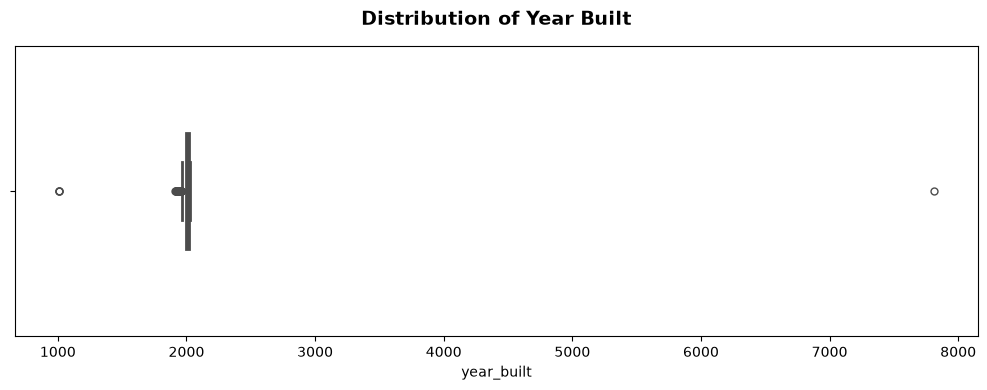

In [21]:
# Box plot 
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df[column], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Distribution of Year Built', fontsize=14, pad=15, fontweight='bold')
plt.xlabel(column)

plt.tight_layout()
plt.show()

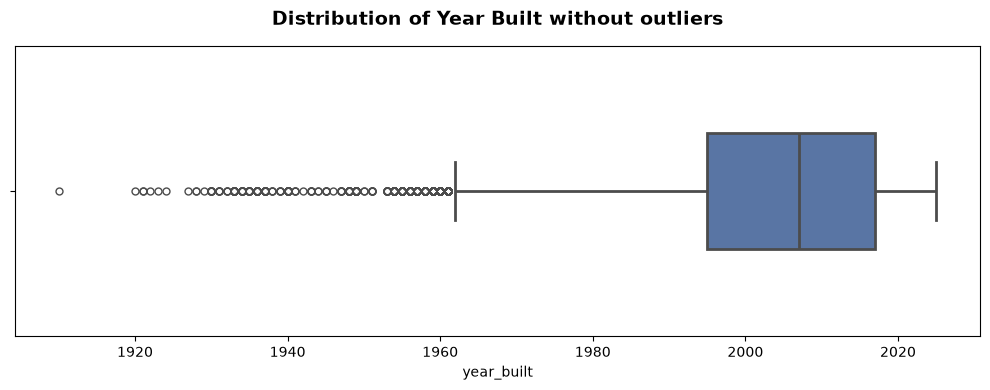

In [22]:
df_clean = df[(df['year_built'] >= 1850) & (df['year_built'] <= 2026)]

plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_clean[column], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Distribution of Year Built without outliers', fontsize=14, pad=15, fontweight='bold')
plt.xlabel(column)

plt.tight_layout()
plt.show()

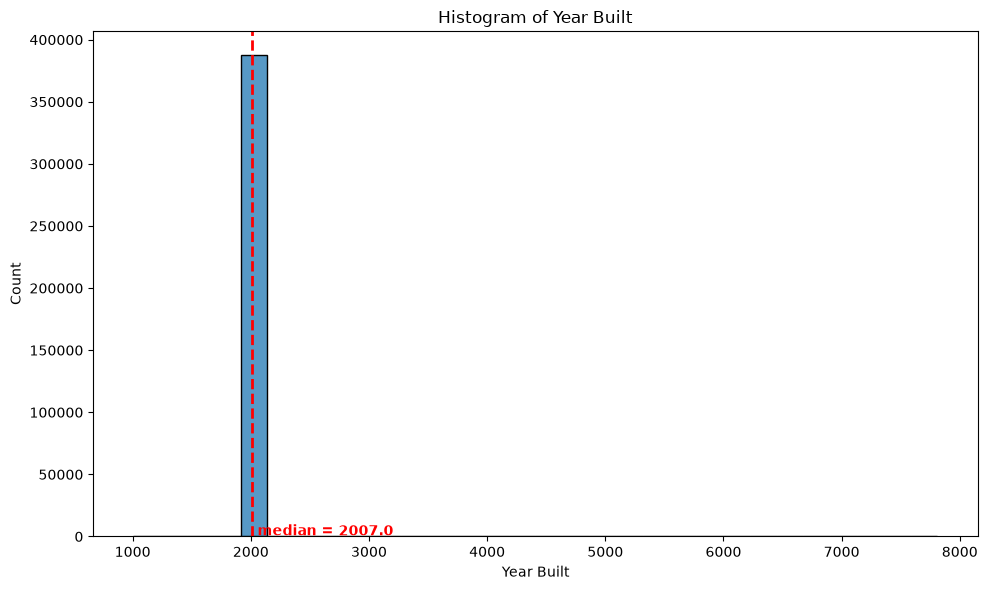

In [23]:
#Histogram
plt.figure(figsize=(10, 6))
sns.histplot(x=df[column], bins=30)

median_year = df[column].median()
plt.axvline(median_year, color='red', linestyle='--', linewidth=2)

plt.text(median_year + 50, 1000, f'median = {median_year}', color='red', fontweight='bold')

plt.title('Histogram of Year Built')
plt.xlabel('Year Built')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

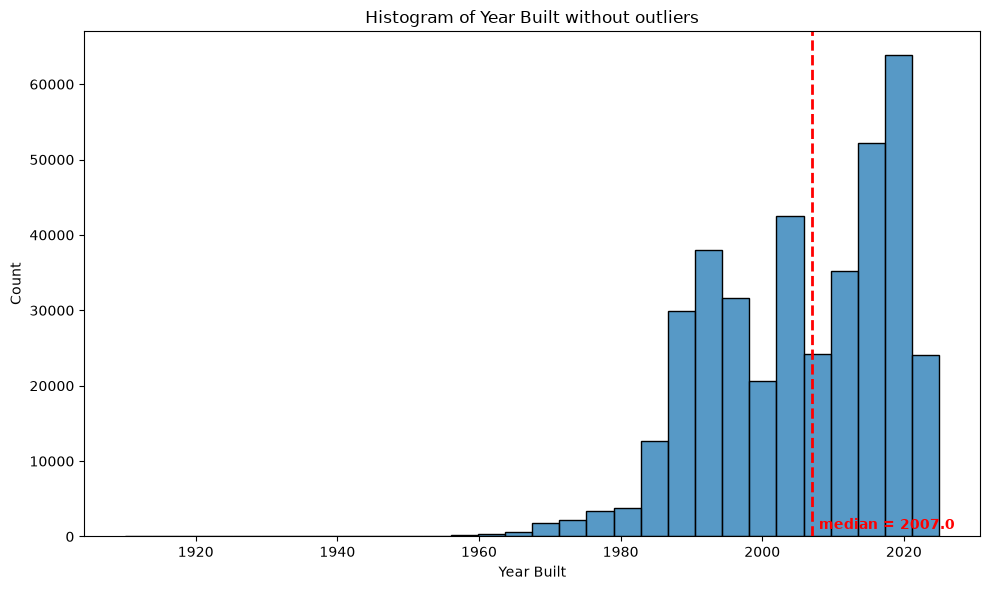

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_clean[column], bins=30)

median_year = df_clean[column].median()
plt.axvline(median_year, color='red', linestyle='--', linewidth=2)

plt.text(median_year + 1, 1000, f'median = {median_year}', color='red', fontweight='bold')

plt.title('Histogram of Year Built without outliers')
plt.xlabel('Year Built')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

We need to calculate the **minimum** and **maximum** values for the 'year_built' column in the cleaned dataset. 

In [25]:
print(f"Minimum built year: {df_copy['year_built'].min()}")
print(f"Maximum built year: {df_copy['year_built'].max()}")

Minimum built year: 1006.0
Maximum built year: 7811.0


### **Remove invalid values in `year_built`**

The IQR method flagged extreme values in `year_built`, but a statistical rule alone is not enough to decide which of them are errors. The `.describe()` summary showed a minimum of 1006 and a maximum of 7811, which are impossible values, while other flagged values may be real, old buildings that simply sit far from the median.

Instead of removing every value flagged by the IQR, I used a **logical range** based on domain knowledge:

- **Upper limit (current year, 2026):** a building cannot have been built in the future, so any later year is a data entry error. Buildings from 2026 would be kept, since they may be newly completed.
- **Lower limit (1850):** residential buildings in Seoul built before this year are not plausible in a rental dataset. The limit is intentionally permissive so that genuinely old buildings are not discarded by mistake.

Only **4 rows** fell outside this range (three with year 1006 and one with year 7811), which is a negligible share of the dataset. After removing them, `year_built` ranges from 1910 to 2025, which is a realistic span for buildings in Seoul.

In [26]:
MIN_YEAR = 1850
MAX_YEAR = date.today().year

rows_before = len(df_copy)

# Rows that will be removed (for documentation)
invalid_years = df_copy[~df_copy['year_built'].between(MIN_YEAR, MAX_YEAR)]
print(f"Invalid year_built values found: {len(invalid_years):,}")
print(invalid_years['year_built'].value_counts().sort_index().head(20))

# Keep only rows inside the valid range
df_copy = df_copy[df_copy['year_built'].between(MIN_YEAR, MAX_YEAR)].reset_index(drop=True)

rows_dropped = rows_before - len(df_copy)
print(f"\nRows before: {rows_before:,} | Rows after: {len(df_copy):,}")
print(f"Rows dropped: {rows_dropped:,} ({rows_dropped / rows_before * 100:.4f}%)")
print(f"year_built range now: {df_copy['year_built'].min():.0f} - {df_copy['year_built'].max():.0f}")

Invalid year_built values found: 4
year_built
1006.0    3
7811.0    1
Name: count, dtype: int64

Rows before: 331,874 | Rows after: 331,870
Rows dropped: 4 (0.0012%)
year_built range now: 1910 - 2025


In [27]:
df_copy.shape

(331870, 23)

Let's analize the numeric variables:
- **deposit_10k_krw:** It's almost certain that this variable is heavily skewed to the right.
- **monthly_rent_10k_krw:** The value is 0 for all jeonse contracts. If you analyze the data without filtering by ‘lease_type,’ you'll likely get a false bimodal distribution (a huge peak at 0). You should analyze only the rows with 'wolse.'
- **leased_area_sqm:** We need to check the minimum and maximum ranges.
- **floor:** There are negative values, which means they belong to basements and therefore cannot be treated as outliers
- **year_built:** We need to check whether there was a construction 'boom' in any specific decade.

### Distribution Analysis of `deposit_10k_krw`

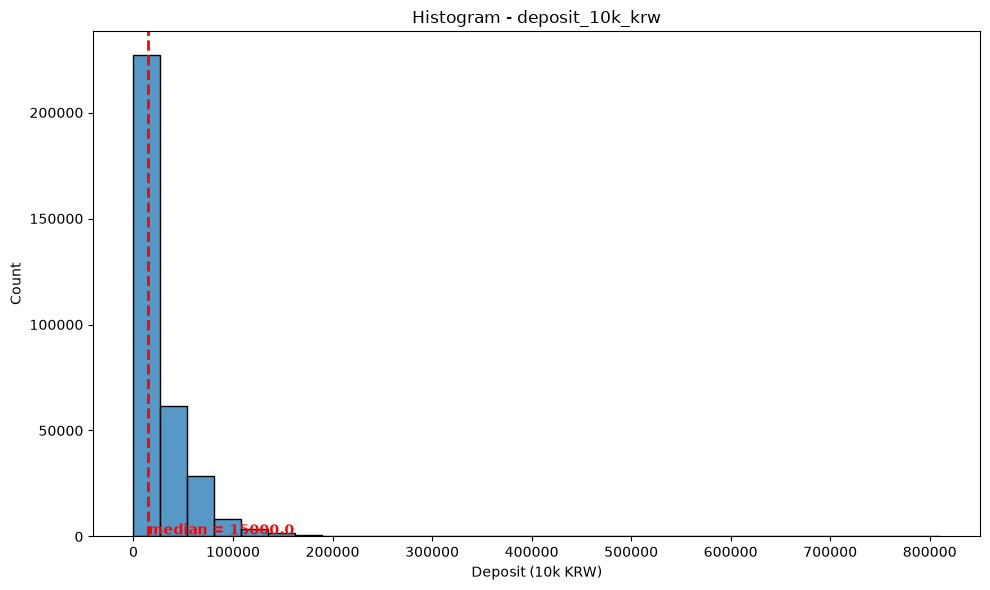

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_copy['deposit_10k_krw'], bins=30)

median_deposit = df_copy['deposit_10k_krw'].median()
plt.axvline(median_deposit, color='red', linestyle='--', linewidth=2)

plt.text(median_deposit + 1, 1000, f'median = {median_deposit}', color='red', fontweight='bold')

plt.title('Histogram - deposit_10k_krw')
plt.xlabel('Deposit (10k KRW)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

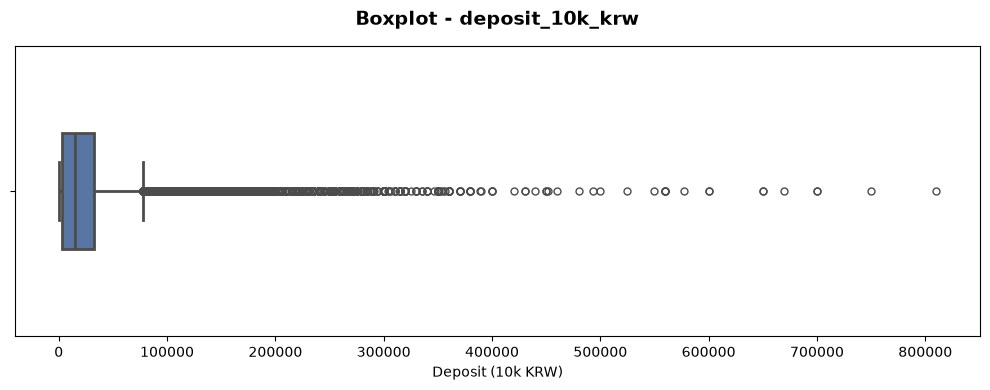

In [29]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_copy['deposit_10k_krw'], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Boxplot - deposit_10k_krw', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Deposit (10k KRW)')

plt.tight_layout()
plt.show()

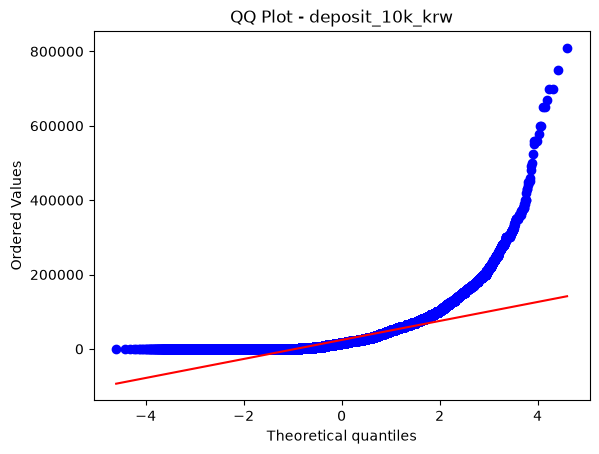

In [30]:
stats.probplot(df_copy['deposit_10k_krw'], dist="norm", plot=plt)
plt.title('QQ Plot - deposit_10k_krw')
plt.show()

In [31]:
df_copy['deposit_10k_krw'].mean(), df_copy['deposit_10k_krw'].median()

(np.float64(24089.324211287552), np.float64(15000.0))

In [32]:
df_copy['deposit_10k_krw'].skew()

np.float64(2.9848127340871637)

In [33]:
Q1 = df_copy['deposit_10k_krw'].quantile(0.25)
Q3 = df_copy['deposit_10k_krw'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_copy[(df_copy['deposit_10k_krw'] < lower_bound) | (df_copy['deposit_10k_krw'] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Lower bound: -42000.0
Upper bound: 78000.0
Number of outliers: 17233


### Interpretation — `deposit_10k_krw`

The distribution of `deposit_10k_krw` is strongly right-skewed (skew ≈ 3.07), confirmed by the large gap between the mean (22,838) and the median (14,000). This pattern is typical of price/money variables: a small group of very high-value deposits (up to 800,000, i.e. ~8 billion KRW) pulls the mean upward without representing the typical contract.

The IQR method flags 17,238 rows (≈5.2% of the dataset) as outliers. Unlike the invalid values found in `year_built`, these are not data entry errors — they correspond to real, high-value properties (likely premium apartments in central districts). Removing them would artificially bias the analysis downward, so they will be **kept** for now.

The QQ plot shows points following the theoretical normal line reasonably well in the center, but curving sharply upward at the right tail — a visual signature consistent with a lognormal-like distribution. This suggests that a **log transformation** (`np.log1p`) should be considered before using this variable in linear regression, since linear models perform better with more symmetric distributions. This decision is deferred to the feature engineering phase.

### Distribution Analysis of `monthly_rent_10k_krw`

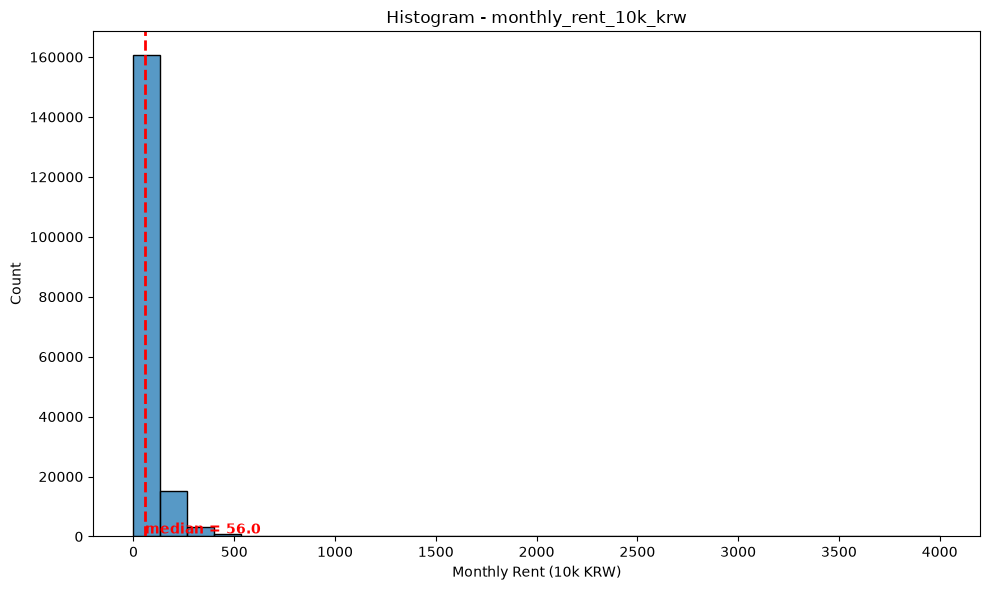

In [34]:
df_wolse = df_copy[df_copy['lease_type'] == 'Monthly rent']

plt.figure(figsize=(10, 6))
sns.histplot(x=df_wolse['monthly_rent_10k_krw'], bins=30)

median_monthly_rent = df_wolse['monthly_rent_10k_krw'].median()
plt.axvline(median_monthly_rent, color='red', linestyle='--', linewidth=2)

plt.text(median_monthly_rent + 1, 1000, f'median = {median_monthly_rent}', color='red', fontweight='bold')

plt.title('Histogram - monthly_rent_10k_krw')
plt.xlabel('Monthly Rent (10k KRW)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

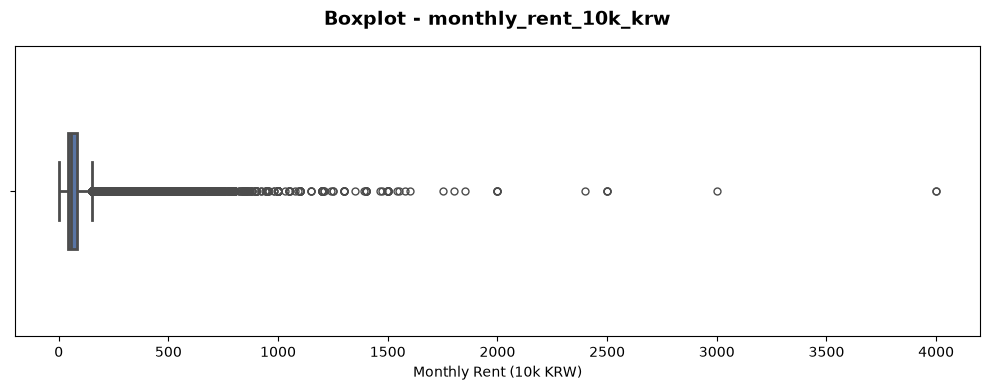

In [35]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_wolse['monthly_rent_10k_krw'], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Boxplot - monthly_rent_10k_krw', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Monthly Rent (10k KRW)')

plt.tight_layout()
plt.show()

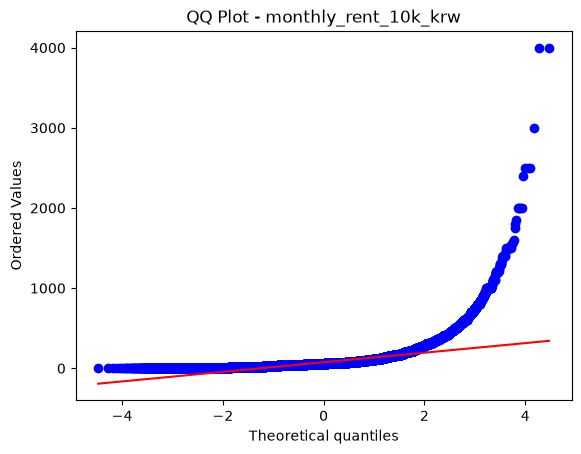

In [36]:
stats.probplot(df_wolse['monthly_rent_10k_krw'], dist="norm", plot=plt)
plt.title('QQ Plot - monthly_rent_10k_krw')
plt.show()

In [37]:
df_wolse['monthly_rent_10k_krw'].mean(), df_wolse['monthly_rent_10k_krw'].median()

(np.float64(74.92708171809583), np.float64(56.0))

In [38]:
df_wolse['monthly_rent_10k_krw'].skew()

np.float64(7.309109633442407)

In [39]:
Q1 = df_wolse['monthly_rent_10k_krw'].quantile(0.25)
Q3 = df_wolse['monthly_rent_10k_krw'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_wolse[(df_wolse['monthly_rent_10k_krw'] < lower_bound) | (df_wolse['monthly_rent_10k_krw'] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Lower bound: -26.0
Upper bound: 150.0
Number of outliers: 15159


### Interpretation — `monthly_rent_10k_krw` (Wolse only)

After filtering to Monthly rent (Wolse) contracts only (`n = 180583`, ≈ 54.41% of the dataset), the distribution shows a mean of 74.93, a median of 56.0, and a skew of 7.31. The skew is still very high — in fact slightly higher than in the unfiltered version (6.88) — because removing the large mass of zero-rent Jeonse contracts leaves only the right tail of real monthly rents, which increases the relative skewness. The gap between mean and median (74.93 vs. 56.0) is proportionally similar to before, confirming that even among genuine Wolse contracts, a small group of very high-rent properties pulls the mean upward.

The IQR method flags 15,166 rows as outliers under this filtered view. As with the deposit variable, these likely reflect real high-end rental contracts (rents in the 2,000–4,000 range, i.e. 20–40 million KRW/month) rather than data errors, so they are kept. A log transformation will also be considered for this variable at the modeling stage, given the persistent right skew typical of rent data.

### Distribution Analysis of `leased_area_sqm`

We need to parse de `leased_area_sqm` from str to float to do the analysis

In [40]:
df_copy['leased_area_sqm'] = (
    df_copy['leased_area_sqm']
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [41]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 331870 entries, 0 to 331869
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   registration_year              331870 non-null  int64         
 1   district_code                  331870 non-null  int64         
 2   district_name                  331870 non-null  str           
 3   legal_dong_code                331870 non-null  int64         
 4   legal_dong_name                331870 non-null  str           
 5   lot_type_code                  331870 non-null  float64       
 6   lot_type                       331870 non-null  str           
 7   floor                          257762 non-null  float64       
 8   contract_date                  331870 non-null  str           
 9   lease_type                     331870 non-null  str           
 10  leased_area_sqm                331870 non-null  float64       
 11  deposit_10k

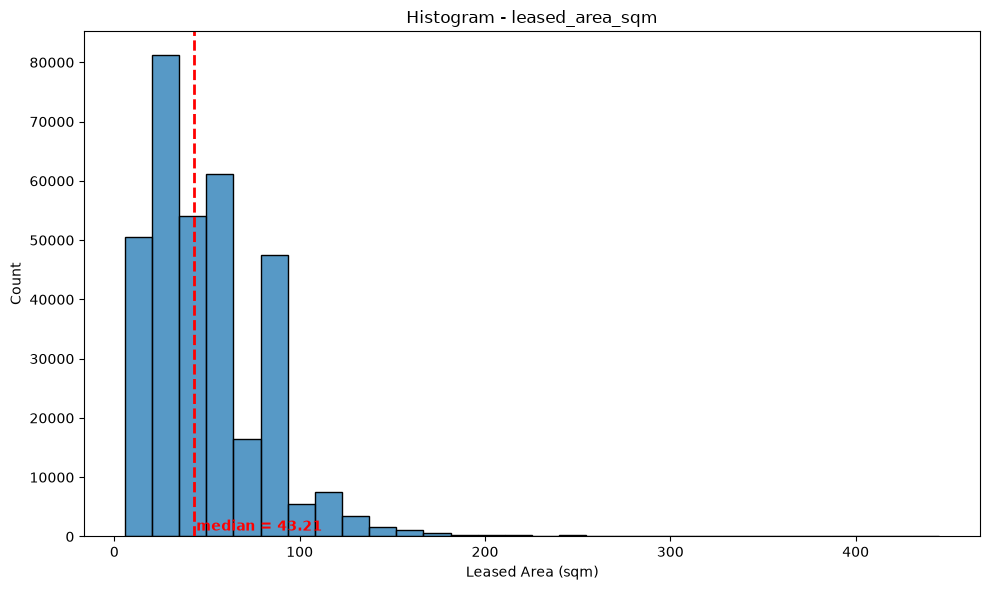

In [42]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_copy['leased_area_sqm'], bins=30)

median_leased_area = df_copy['leased_area_sqm'].median()
plt.axvline(median_leased_area, color='red', linestyle='--', linewidth=2)

plt.text(median_leased_area + 1, 1000, f'median = {median_leased_area}', color='red', fontweight='bold')

plt.title('Histogram - leased_area_sqm')
plt.xlabel('Leased Area (sqm)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

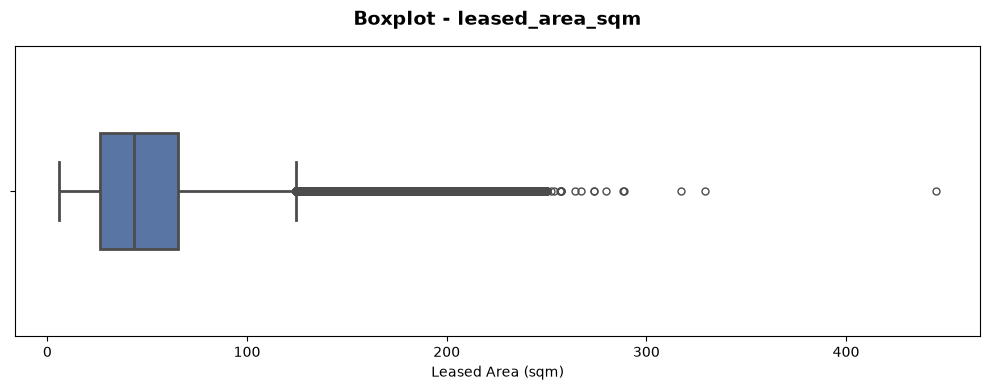

In [43]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_copy['leased_area_sqm'], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Boxplot - leased_area_sqm', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Leased Area (sqm)')

plt.tight_layout()
plt.show()

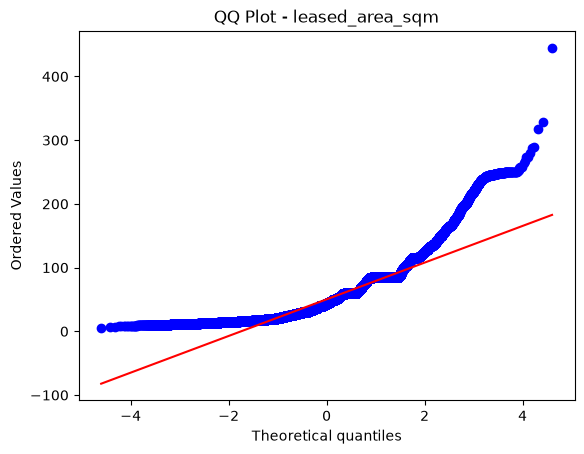

In [44]:
stats.probplot(df_copy['leased_area_sqm'], dist="norm", plot=plt)
plt.title('QQ Plot - leased_area_sqm')
plt.show()

In [45]:
df_copy['leased_area_sqm'].mean(), df_copy['leased_area_sqm'].median()

(np.float64(50.29256510380571), np.float64(43.21))

In [46]:
df_copy['leased_area_sqm'].skew()

np.float64(1.408398333374996)

In [47]:
Q1 = df_copy['leased_area_sqm'].quantile(0.25)
Q3 = df_copy['leased_area_sqm'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_copy[(df_copy['leased_area_sqm'] < lower_bound) | (df_copy['leased_area_sqm'] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Lower bound: -32.475000000000016
Upper bound: 124.52500000000002
Number of outliers: 7541


### Interpretation — `leased_area_sqm`

This variable shows a more moderate right skew (≈1.41) compared to the monetary variables, which is expected given that living space has a more natural physical ceiling than price. 

The histogram reveals several distinct peaks (around 20–30, 40–50, 60–70 and 80–90 sqm) rather than a smooth curve. This is likely explained by **standardized apartment unit sizes** common in South Korean construction (e.g. units marketed as 59㎡ or 84㎡), rather than random noise — a pattern worth highlighting in the business insights section.

The IQR method flags 7,538 outliers, with a maximum value of ~450 sqm. This range is plausible for a residential dataset (large houses or penthouses), but the extreme upper values should be spot-checked to rule out unit-conversion errors (e.g. values entered in pyeong instead of square meters) before deciding whether to keep or cap them.

### Distribution Analysis of `floor`

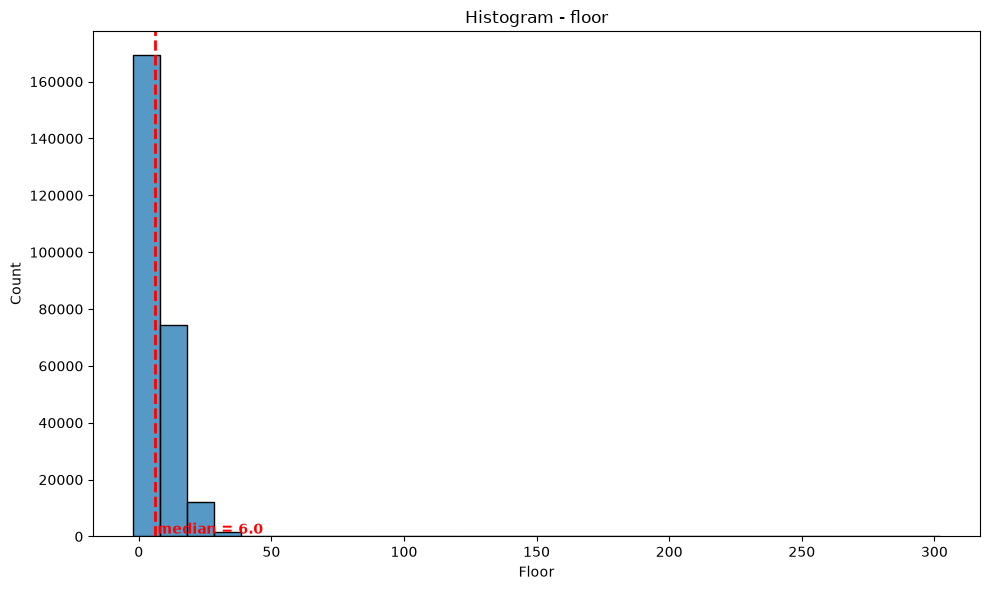

In [48]:
plt.figure(figsize=(10, 6))
sns.histplot(x=df_copy['floor'], bins=30)

median_floor = df_copy['floor'].median()
plt.axvline(median_floor, color='red', linestyle='--', linewidth=2)

plt.text(median_floor + 1, 1000, f'median = {median_floor}', color='red', fontweight='bold')

plt.title('Histogram - floor')
plt.xlabel('Floor')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

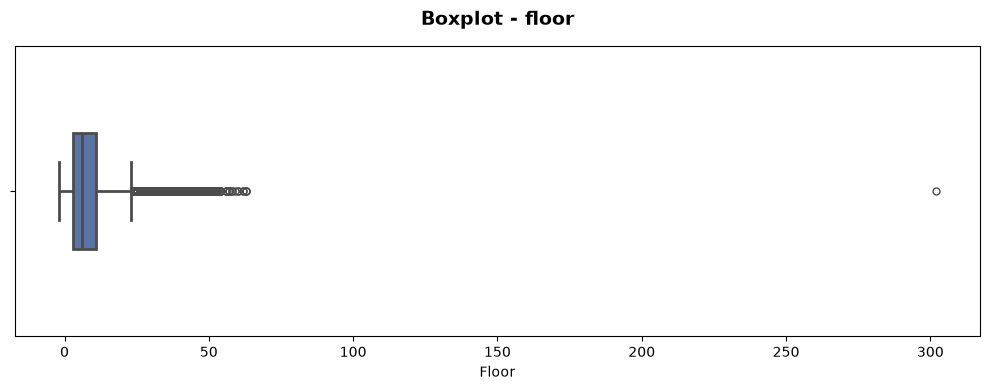

In [49]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_copy['floor'], 
    color="#4C72B0",
    width=0.4,
    fliersize=5,
    linewidth=2
)

plt.title('Boxplot - floor', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Floor')

plt.tight_layout()
plt.show()

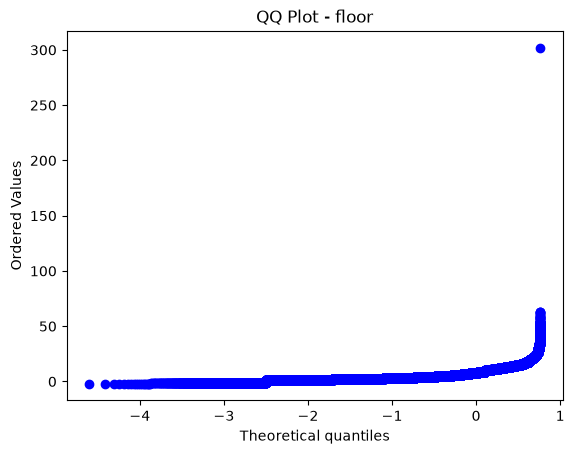

In [50]:
stats.probplot(df_copy['floor'], dist="norm", plot=plt)
plt.title('QQ Plot - floor')
plt.show()

In [51]:
df_copy['floor'].mean(), df_copy['floor'].median()

(np.float64(7.505152039478278), np.float64(6.0))

In [52]:
df_copy['floor'].skew()

np.float64(1.9949605216867083)

In [53]:
Q1 = df_copy['floor'].quantile(0.25)
Q3 = df_copy['floor'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_copy[(df_copy['floor'] < lower_bound) | (df_copy['floor'] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Lower bound: -9.0
Upper bound: 23.0
Number of outliers: 5339


### Interpretation — `floor`

The `floor` variable shows a moderate-to-high right skew (≈2.0), with most contracts concentrated in low-to-mid floors (median = 6). 

However, the maximum value of 300 is not a plausible floor number for a residential building — even Seoul's tallest mixed-use building (Lotte World Tower) has around 123 floors, and no purely residential building approaches 300. This indicates a **data entry error**, not a legitimate extreme value.

Rather than applying the IQR-based upper bound (23.0), which would incorrectly discard genuinely tall but valid residential buildings, a domain-based logical range will be defined (similar to the approach used for `year_built`), and rows outside that range will be removed in the data cleaning section.

### Remove invalid values in `floor`

The maximum value of `floor` is 300, which is not plausible for a residential building. As done with `year_built`, a logical range based on domain knowledge is used instead of the IQR bound. Missing values (`NaN`) are kept, since they mostly correspond to detached houses that have no floor number.

In [54]:
df_copy.loc[df_copy['floor'] > 70, ['district_name', 'building_type', 'floor', 'year_built']].sort_values('floor', ascending=False)

,district_name,building_type,floor,year_built
111250,Gwangjin-gu,Row house / Villa (multi-unit),302.0,2018.0


In [55]:
MAX_FLOOR = 100
rows_before = len(df_copy)

df_copy = df_copy[df_copy['floor'].isna() | (df_copy['floor'] <= MAX_FLOOR)].reset_index(drop=True)

print(f"Rows dropped: {rows_before - len(df_copy):,}")
print(f"floor max now: {df_copy['floor'].max()}")

Rows dropped: 1
floor max now: 63.0


### Recreate lease-type subsets

After cleaning `floor`, the Wolse subset is rebuilt so that it matches the current `df_copy`, and a Jeonse subset is created for the following analysis.

In [56]:
df_wolse = df_copy[df_copy['lease_type'] == 'Monthly rent']
df_jeonse = df_copy[df_copy['lease_type'] == 'Jeonse (deposit only)']

print(f"Wolse: {len(df_wolse):,} rows | Jeonse: {len(df_jeonse):,} rows")

Wolse: 180,572 rows | Jeonse: 151,297 rows


Now, let's analize the categorical variables:
- **district_name:** Are the 25 districts represented in a reasonably balanced way, or are there 3–4 districts that dominate the dataset?
- **building_type:** We need the proportion of apartments / officetels / villas / single-family homes. This is key data for your focus on foreigners/students (officetels are typically the go-to option for short-term stays).
- **lease_type:** We need the proportion of jeonse vs. wolse—this is directly your future classification target variable, so you need to know upfront whether it’s balanced or not.
- **contract_type:** New contract vs. renewal, and how many values are blank
- **renewal_right_used:** Same logic—frequency of yes/no/blank.

In [57]:
def analyze_categorical(df, column):
    """
    Univariate analysis for a categorical column:
    frequency table (absolute + percentage) and bar plot.
    """
    freq_table = df[column].value_counts(dropna=False)
    pct_table = df[column].value_counts(normalize=True, dropna=False) * 100

    summary = pd.DataFrame({
        'count': freq_table,
        'percentage': pct_table.round(2)
    })

    print(f"--- {column} ---")
    print(summary)

    plt.figure(figsize=(10, 6))
    order = freq_table.index
    sns.barplot(x=freq_table.values, y=order, orient='h')
    plt.title(f'Frequency - {column}')
    plt.xlabel('Count')
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

    return summary

--- district_name ---
                 count  percentage
district_name                     
Songpa-gu        27806        8.38
Gangseo-gu       22461        6.77
Gangnam-gu       21863        6.59
Gwanak-gu        18228        5.49
Mapo-gu          17645        5.32
Gangdong-gu      16836        5.07
Yeongdeungpo-gu  16797        5.06
Seocho-gu        16216        4.89
Gwangjin-gu      15104        4.55
Dongjak-gu       14350        4.32
Nowon-gu         13610        4.10
Eunpyeong-gu     13094        3.95
Dongdaemun-gu    12303        3.71
Yangcheon-gu     12063        3.63
Guro-gu          11235        3.39
Seongbuk-gu      10864        3.27
Jungnang-gu      10840        3.27
Seongdong-gu     10716        3.23
Seodaemun-gu     10306        3.11
Yongsan-gu        8854        2.67
Geumcheon-gu      8127        2.45
Dobong-gu         6988        2.11
Gangbuk-gu        6164        1.86
Jung-gu           4794        1.44
Jongno-gu         4605        1.39


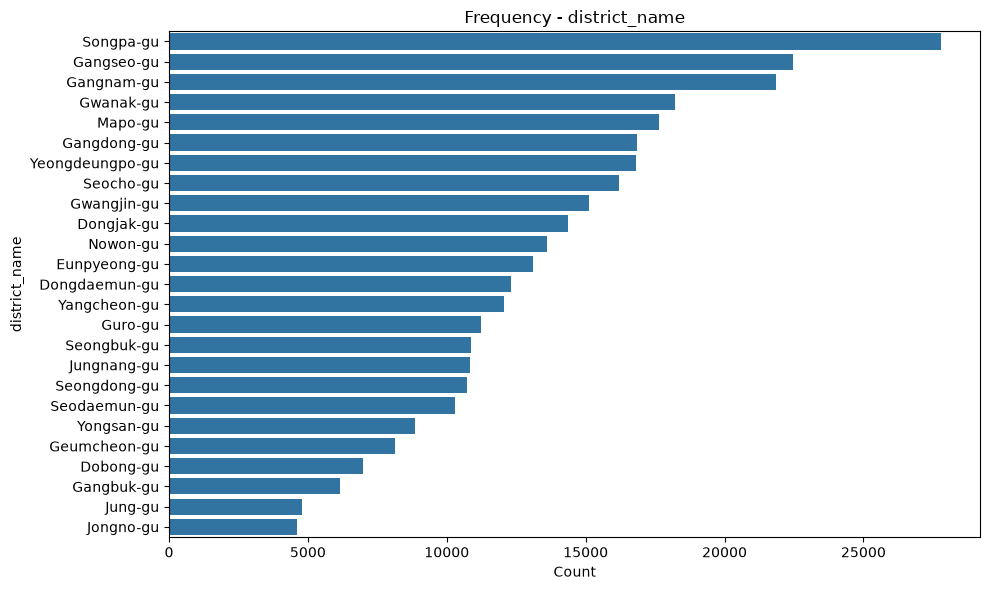

In [58]:
district_summary = analyze_categorical(df_copy, 'district_name')

--- building_type ---
                                   count  percentage
building_type                                       
Apartment                         134467       40.52
Row house / Villa (multi-unit)     77529       23.36
Detached / Multi-household house   74108       22.33
Officetel                          45765       13.79


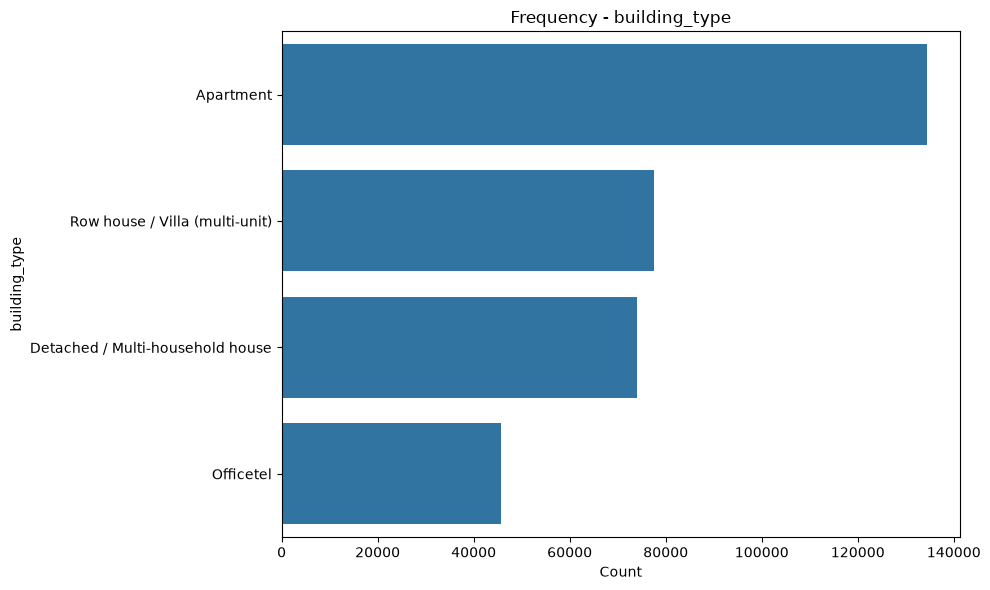

In [59]:
building_type_summary = analyze_categorical(df_copy, 'building_type')

--- lease_type ---
                        count  percentage
lease_type                               
Monthly rent           180572       54.41
Jeonse (deposit only)  151297       45.59


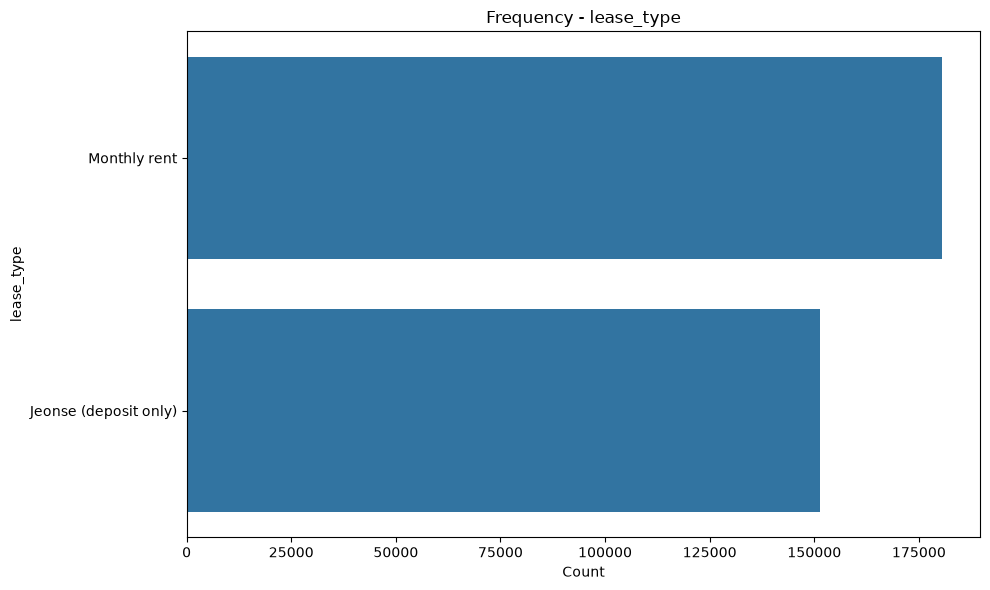

In [60]:
lease_type_summary = analyze_categorical(df_copy, 'lease_type')

--- contract_type ---
                count  percentage
contract_type                    
New            235732       71.03
Renewal         90272       27.20
Not specified    5865        1.77


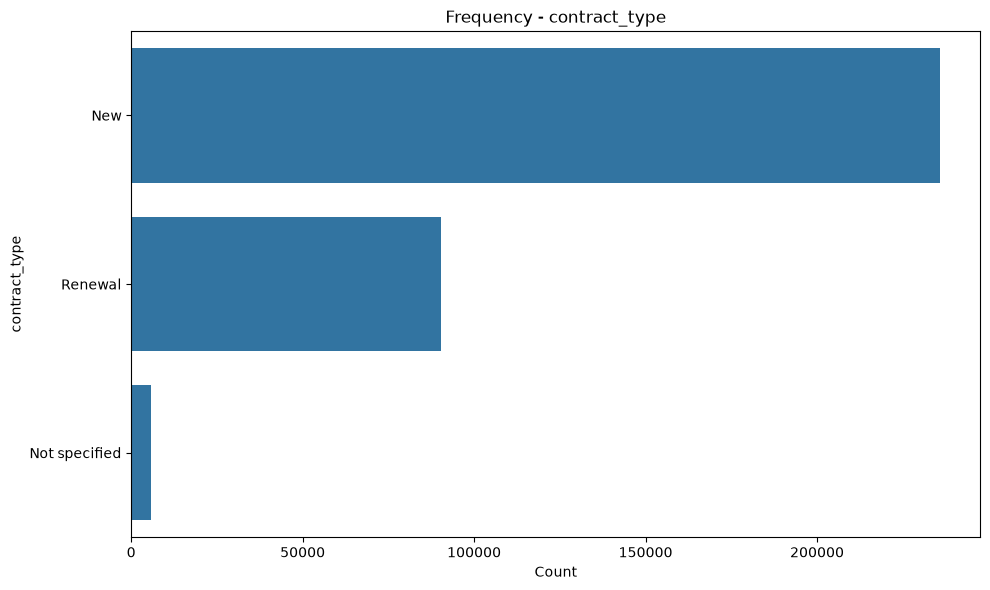

In [61]:
contract_type_summary = analyze_categorical(df_copy, 'contract_type')

--- renewal_right_used ---
                     count  percentage
renewal_right_used                    
No/Not reported     296827       89.44
Yes                  35042       10.56


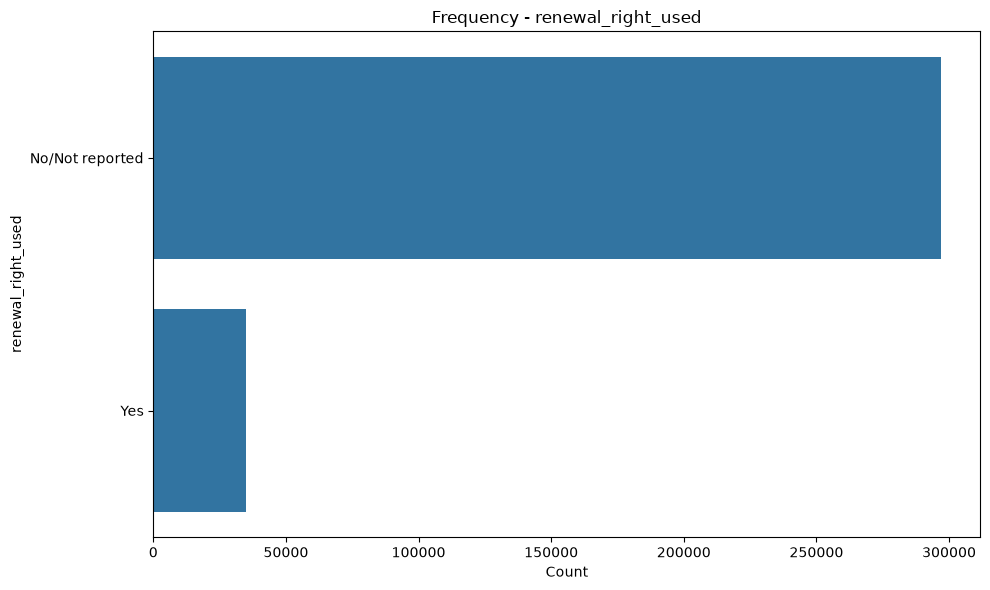

In [62]:
renewal_right_summary = analyze_categorical(df_copy, 'renewal_right_used')

Now let's compare the **deposit_10k_krw** field with other fields to see if there is a correlation between this field and another one

### `deposit_10k_krw` vs. `district_name`

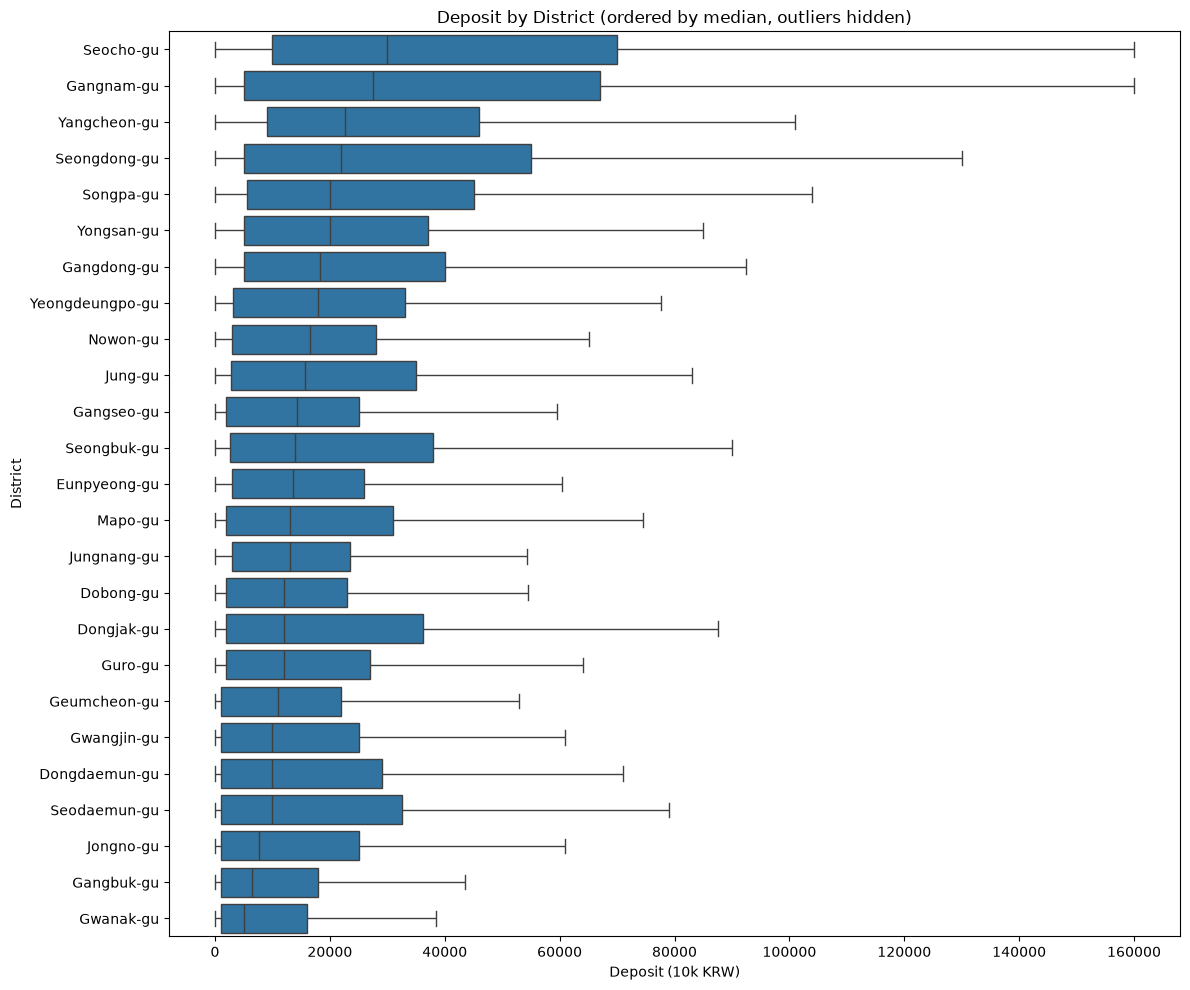

In [63]:
plt.figure(figsize=(12, 10))
order = df_copy.groupby('district_name')['deposit_10k_krw'].median().sort_values(ascending=False).index
sns.boxplot(data=df_copy, x='deposit_10k_krw', y='district_name', order=order, showfliers=False)
plt.title('Deposit by District (ordered by median, outliers hidden)')
plt.xlabel('Deposit (10k KRW)')
plt.ylabel('District')
plt.tight_layout()
plt.show()

### `deposit_10k_krw` vs. `leased_area_sqm`

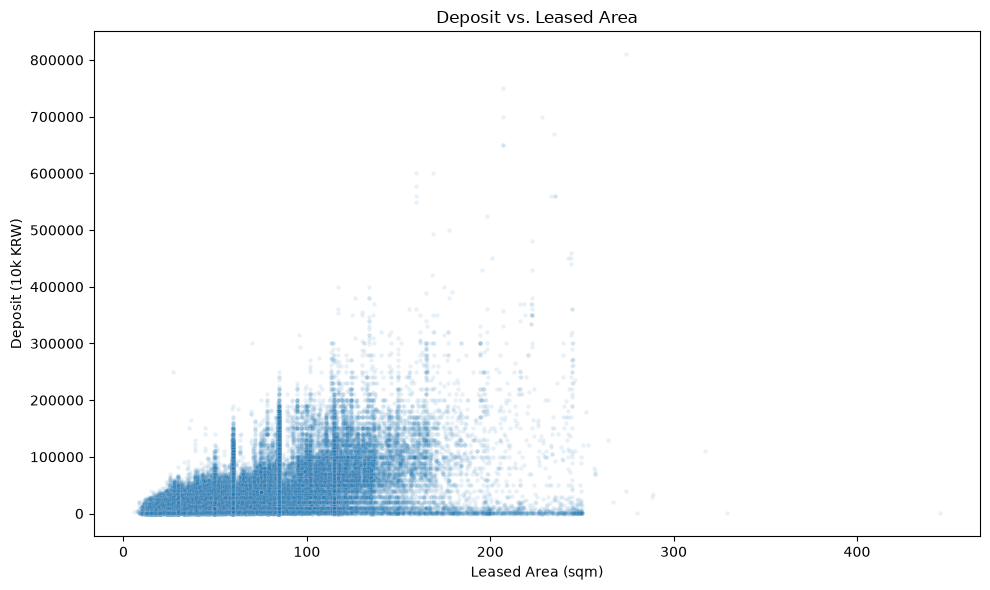

Correlation (leased_area_sqm vs deposit_10k_krw): 0.635


In [64]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='leased_area_sqm', y='deposit_10k_krw', alpha=0.1, s=10)
plt.title('Deposit vs. Leased Area')
plt.xlabel('Leased Area (sqm)')
plt.ylabel('Deposit (10k KRW)')
plt.tight_layout()
plt.show()

correlation = df_copy[['leased_area_sqm', 'deposit_10k_krw']].corr().iloc[0, 1]
print(f"Correlation (leased_area_sqm vs deposit_10k_krw): {correlation:.3f}")

### `deposit_10k_krw` vs. `building_type`

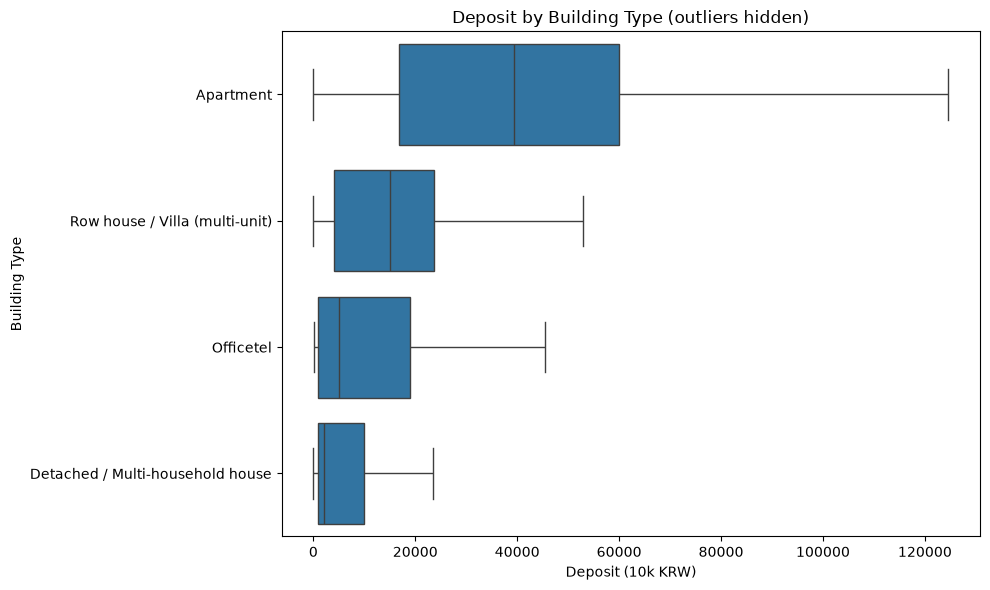

In [65]:
plt.figure(figsize=(10, 6))
order = df_copy.groupby('building_type')['deposit_10k_krw'].median().sort_values(ascending=False).index
sns.boxplot(data=df_copy, x='deposit_10k_krw', y='building_type', order=order, showfliers=False)
plt.title('Deposit by Building Type (outliers hidden)')
plt.xlabel('Deposit (10k KRW)')
plt.ylabel('Building Type')
plt.tight_layout()
plt.show()

### `deposit_10k_krw` vs. `floor`

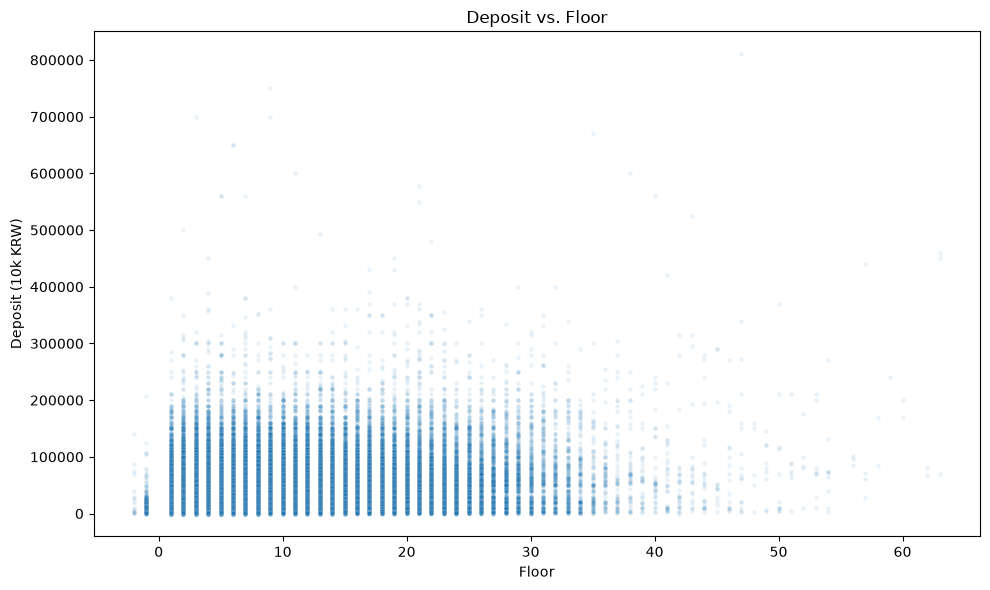

In [66]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='floor', y='deposit_10k_krw', alpha=0.1, s=10)
plt.title('Deposit vs. Floor')
plt.xlabel('Floor')
plt.ylabel('Deposit (10k KRW)')
plt.tight_layout()
plt.show()

### `deposit_10k_krw` vs. `year_built`

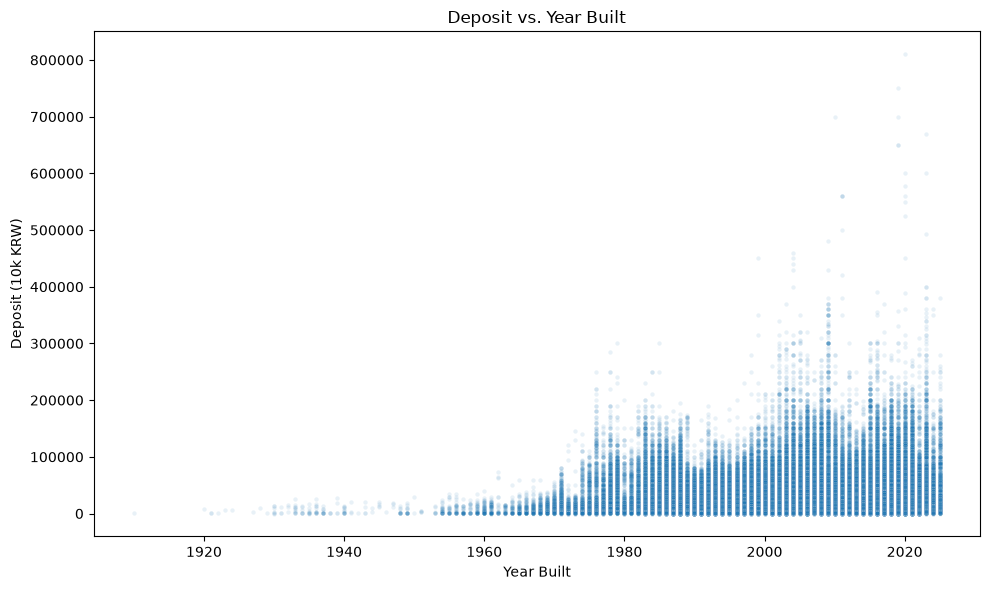

In [67]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_copy, x='year_built', y='deposit_10k_krw', alpha=0.1, s=10)
plt.title('Deposit vs. Year Built')
plt.xlabel('Year Built')
plt.ylabel('Deposit (10k KRW)')
plt.tight_layout()
plt.show()

### `lease_type` vs. `district_name`

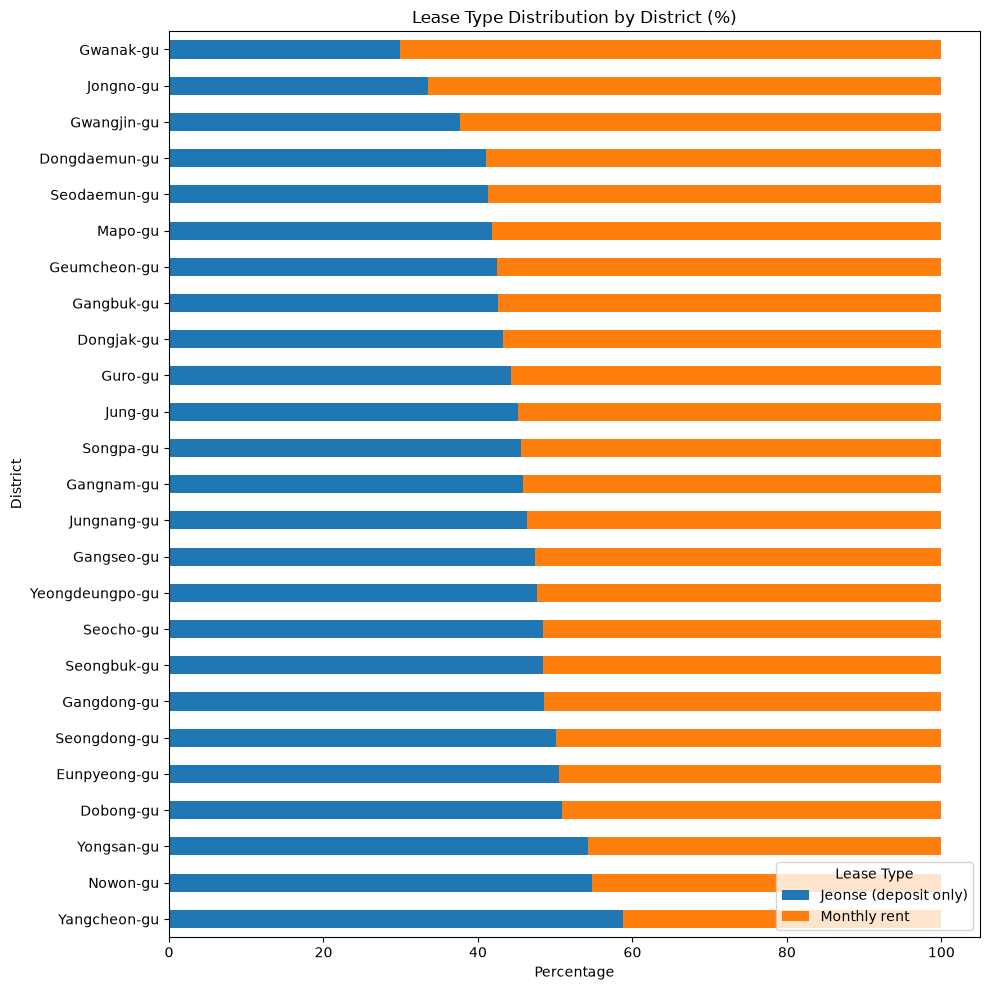

In [68]:
crosstab = pd.crosstab(df_copy['district_name'], df_copy['lease_type'], normalize='index') * 100
crosstab = crosstab.sort_values(by='Jeonse (deposit only)', ascending=False)

crosstab.plot(kind='barh', stacked=True, figsize=(10, 10))
plt.title('Lease Type Distribution by District (%)')
plt.xlabel('Percentage')
plt.ylabel('District')
plt.legend(title='Lease Type', loc='lower right')
plt.tight_layout()
plt.show()

### Correlation analysis

This section measures how strongly the numeric variables move together. Two coefficients are used:

- **Pearson**: measures *linear* association and is sensitive to extreme values.
- **Spearman**: measures *monotonic* association using ranks, so it is robust to outliers and skewed distributions, both present in this dataset.

As a rule of thumb, |r| < 0.3 is considered weak, 0.3–0.7 moderate and > 0.7 strong. The first heatmaps use `deposit_10k_krw`, `leased_area_sqm`, `floor` and `year_built`. `monthly_rent_10k_krw` is analyzed separately on Wolse contracts, because it equals 0 for every Jeonse contract.

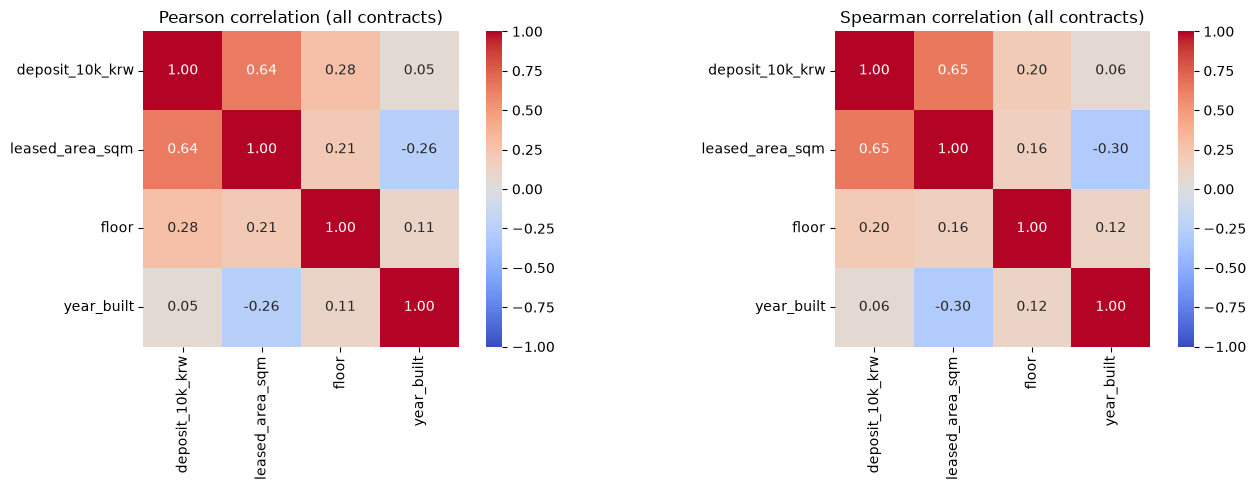

In [69]:
corr_cols = ['deposit_10k_krw', 'leased_area_sqm', 'floor', 'year_built']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, method in zip(axes, ['pearson', 'spearman']):
    corr = df_copy[corr_cols].corr(method=method)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=ax)
    ax.set_title(f'{method.capitalize()} correlation (all contracts)')
plt.tight_layout()
plt.show()

**Interpretation (all contracts).** The variable most associated with `deposit_10k_krw` is `leased_area_sqm`, with a moderate-to-strong positive correlation (Pearson = 0.64, Spearman = 0.65). `floor` shows a weak positive correlation (Spearman = 0.20) and `year_built` shows practically none (Spearman = 0.06).

Pearson and Spearman are almost identical for the deposit–area pair, so this relationship is not driven by extreme values. For `floor`, Pearson (0.28) is higher than Spearman (0.20), which suggests that a few very high floors with very high deposits inflate the linear coefficient.

`year_built` is negatively correlated with `leased_area_sqm` (Spearman = −0.30): newer buildings tend to have smaller units. This may offset the premium that newer buildings carry, which would explain why construction year shows almost no overall association with deposit despite the higher deposit ceiling observed in the scatter plot.

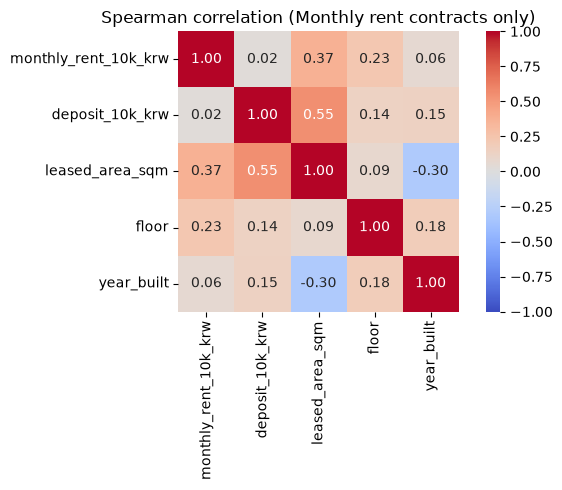

In [70]:
corr_cols_wolse = ['monthly_rent_10k_krw', 'deposit_10k_krw', 'leased_area_sqm', 'floor', 'year_built']

plt.figure(figsize=(7, 5))
sns.heatmap(df_wolse[corr_cols_wolse].corr(method='spearman'), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Spearman correlation (Monthly rent contracts only)')
plt.tight_layout()
plt.show()

**Interpretation (Wolse contracts).** Among Monthly rent contracts, `monthly_rent_10k_krw` is most associated with `leased_area_sqm` (Spearman = 0.37), followed by `floor` (0.23). Its correlation with `year_built` is negligible (0.06).

The correlation between monthly rent and deposit is practically zero (Spearman = 0.02): contracts with a larger deposit do not systematically pay a higher or lower monthly rent. This is consistent with a deposit–rent trade-off in the Korean Wolse market, where the same property can be rented with a high deposit and a low rent or the opposite, although this dataset alone cannot confirm that mechanism. Deposit remains strongly associated with area within Wolse contracts (0.55).

In [71]:
for lease, group in df_copy.groupby('lease_type'):
    r = group['deposit_10k_krw'].corr(group['leased_area_sqm'], method='spearman')
    print(f"{lease}: Spearman(deposit, area) = {r:.3f}")

Jeonse (deposit only): Spearman(deposit, area) = 0.759
Monthly rent: Spearman(deposit, area) = 0.548


**Area vs. deposit by lease type.** The Spearman correlation between `leased_area_sqm` and `deposit_10k_krw` is 0.759 for Jeonse and 0.548 for Monthly rent, compared with 0.635 (Pearson) on the pooled data. Area is therefore a much stronger signal of price in Jeonse contracts, and pooling both types dilutes the relationship. For this reason `lease_type` will be considered explicitly in the modeling phase, either as a feature or by fitting separate models.

In [72]:
corr = df_copy[corr_cols].corr(method='spearman')
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack().rename('corr').reset_index()
pairs[pairs['corr'].abs() > 0.7]

,level_0,level_1,corr


**Multicollinearity check.** No pair of numeric variables exceeds |0.7| (Spearman), so multicollinearity is not a concern at this stage. The strongest pair is `deposit_10k_krw` – `leased_area_sqm` (0.65), and among the predictors the largest association is `leased_area_sqm` – `year_built` (−0.30). VIF will be re-checked during feature engineering once new variables are created.

## Temporal and geographic analysis

### Evolution over time

`contract_date` was converted to a datetime and aggregated by month. Jeonse deposits and Wolse monthly rents are analyzed separately, using the **median** because both variables are strongly right-skewed.

Three limitations apply:
- The dataset is a random sample of the original records, so the **absolute number of contracts per month does not represent real market volume**; only relative differences between months are informative.
- January 2026 contains only 11 records, so it was removed to avoid a misleading last data point.
- A change in the median can also be caused by a change in the mix of districts or unit sizes, which is why the Jeonse trend is also checked per square meter.

In [73]:
df_copy['contract_date'] = pd.to_datetime(df_copy['contract_date'])
df_copy['contract_month'] = df_copy['contract_date'].dt.to_period('M').dt.to_timestamp()

# Check coverage first: drop partial months/years at the edges if needed
df_copy['contract_month'].value_counts().sort_index()

contract_month
2022-01-01    7259
2022-02-01    7606
2022-03-01    7134
2022-04-01    6969
2022-05-01    6588
2022-06-01    6165
2022-07-01    6639
2022-08-01    6054
2022-09-01    5214
2022-10-01    3722
2022-11-01    5176
2022-12-01    5701
2023-01-01    6226
2023-02-01    7623
2023-03-01    7457
2023-04-01    6604
2023-05-01    6733
2023-06-01    6536
2023-07-01    6624
2023-08-01    6336
2023-09-01    5774
2023-10-01    6862
2023-11-01    6651
2023-12-01    6967
2024-01-01    7841
2024-02-01    6258
2024-03-01    6633
2024-04-01    6426
2024-05-01    7248
2024-06-01    7280
2024-07-01    7481
2024-08-01    7462
2024-09-01    6098
2024-10-01    7441
2024-11-01    6891
2024-12-01    7225
2025-01-01    7503
2025-02-01    9401
2025-03-01    8622
2025-04-01    7730
2025-05-01    8078
2025-06-01    8163
2025-07-01    8061
2025-08-01    7778
2025-09-01    7209
2025-10-01    6896
2025-11-01    7409
2025-12-01    6104
2026-01-01      11
Name: count, dtype: int64

**Contract activity by month.** The number of contracts per month is relatively stable at about 6,000–8,000 between 2022 and 2025, with a recurring peak in the first quarter of each year (February–March 2023, January 2024 and February 2025, the maximum, with ≈9,400 records). This is consistent with the typical winter–spring moving season in Korea. Lower points tend to appear in autumn, and October 2022 (≈3,700) is a clear anomaly compared with its neighbors (≈5,200 in both September and November), which may reflect a gap in the source data. The drop in December 2025 (≈6,100) may be due to contracts not yet registered at the time of extraction. 2025 also has more records per month than previous years, which should be read as a feature of the sample rather than as market growth.

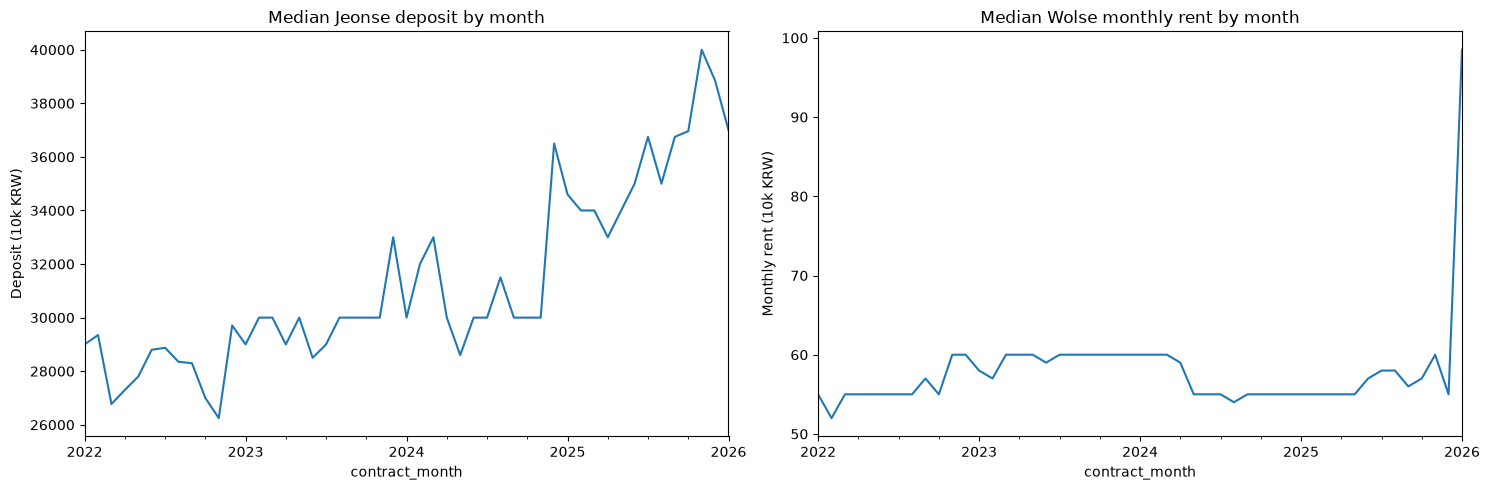

In [74]:
df_jeonse = df_copy[df_copy['lease_type'] == 'Jeonse (deposit only)']
df_wolse = df_copy[df_copy['lease_type'] == 'Monthly rent']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_jeonse.groupby('contract_month')['deposit_10k_krw'].median().plot(ax=axes[0])
axes[0].set_title('Median Jeonse deposit by month')
axes[0].set_ylabel('Deposit (10k KRW)')

df_wolse.groupby('contract_month')['monthly_rent_10k_krw'].median().plot(ax=axes[1])
axes[1].set_title('Median Wolse monthly rent by month')
axes[1].set_ylabel('Monthly rent (10k KRW)')
plt.tight_layout()
plt.show()

**Interpretation.** The median Jeonse deposit shows a clear upward trend: it stays around 28,000–30,000 (10k KRW) throughout 2022 and 2023, steps up to about 34,000–37,000 during 2025 and peaks near 40,000 at the end of the period, an increase of roughly 25–35%. The rise is not gradual: it is concentrated around the turn of 2024–2025.

The median Wolse monthly rent, in contrast, is essentially flat at 55–60 (10k KRW, i.e. 550,000–600,000 KRW) across the four years. Because rents are usually set in round amounts, the median moves in coarse steps and is a blunt indicator; the mean, upper quartiles or rent per sqm would be more sensitive to small changes.

In this sample, the upward pressure on prices therefore shows up mainly in Jeonse deposits rather than in the typical Wolse rent.

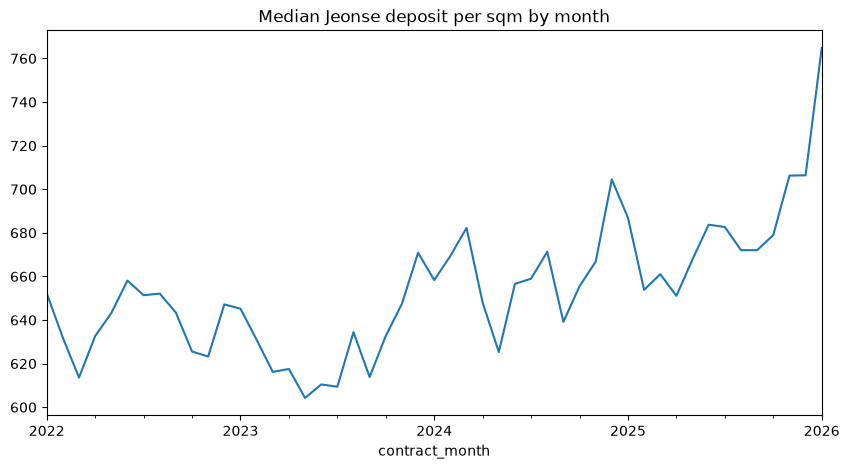

In [75]:
df_jeonse = df_jeonse.assign(deposit_per_sqm=df_jeonse['deposit_10k_krw'] / df_jeonse['leased_area_sqm'])
df_jeonse.groupby('contract_month')['deposit_per_sqm'].median().plot(figsize=(10, 5), title='Median Jeonse deposit per sqm by month')
plt.show()

**Deposit per square meter.** When normalized by area, the upward trend is much milder: the median Jeonse deposit per sqm moves from roughly 600–660 (10k KRW/sqm) in 2022–2023 to about 650–710 in 2025, an increase in the order of 5–10%. A large part of the rise in the raw median deposit may therefore reflect a change in the mix of units (for example, larger units in recent contracts) rather than a rise in the price per sqm alone. Comparing the median area by year (see the summary table) helps to confirm this.

In [76]:
jeonse_rank = (df_jeonse.groupby('district_name')['deposit_10k_krw']
               .agg(median='median', mean='mean', n='size')
               .sort_values('median', ascending=False))

wolse_rank = (df_wolse.groupby('district_name')
              .agg(median_rent=('monthly_rent_10k_krw', 'median'),
                   median_deposit=('deposit_10k_krw', 'median'),
                   n=('monthly_rent_10k_krw', 'size'))
              .sort_values('median_rent', ascending=False))

display(jeonse_rank.head(5)); display(jeonse_rank.tail(5))
display(wolse_rank.head(5)); display(wolse_rank.tail(5))

,median,mean,n
district_name,,,
Gangnam-gu,57750.0,69167.824339,10025
Seocho-gu,55694.0,72183.508025,7850
Seongdong-gu,50600.0,51398.813733,5374
Songpa-gu,40000.0,49627.118600,12656
Dongjak-gu,36750.0,41310.206613,6200


,median,mean,n
district_name,,,
Jungnang-gu,23000.0,26619.997809,5020
Dobong-gu,22000.0,24790.756818,3557
Gwanak-gu,22000.0,27430.420096,5444
Geumcheon-gu,21000.0,23375.742104,3451
Gangbuk-gu,19000.0,23817.072436,2623


,median_rent,median_deposit,n
district_name,,,
Gangnam-gu,90.0,8000.0,11838
Seocho-gu,80.0,10000.0,8366
Jung-gu,71.0,3000.0,2628
Yongsan-gu,70.0,5000.0,4055
Seongdong-gu,66.0,5000.0,5342


,median_rent,median_deposit,n
district_name,,,
Gangbuk-gu,50.0,1000.0,3541
Dongjak-gu,50.0,2000.0,8150
Gwanak-gu,50.0,2000.0,12784
Guro-gu,50.0,3000.0,6265
Jungnang-gu,47.0,3000.0,5820


**Interpretation.** Ranking each lease type separately removes the contract-mix effect seen in the bivariate analysis.

For **Jeonse**, the most expensive districts by median deposit are Gangnam-gu (57,750), Seocho-gu (55,694), Seongdong-gu (50,600), Songpa-gu (40,000) and Dongjak-gu (36,750), all in 10k KRW. The cheapest are Gangbuk-gu (19,000), Geumcheon-gu (21,000), Gwanak-gu and Dobong-gu (22,000 each) and Jungnang-gu (23,000). The median deposit in Gangnam-gu is about three times that of Gangbuk-gu. Gwanak-gu ranked lowest in the pooled boxplot, but within Jeonse contracts it sits level with Dobong-gu: its very low pooled median reflects mostly its high share of Wolse contracts.

For **Wolse**, the highest median monthly rents are in Gangnam-gu (90), Seocho-gu (80), Jung-gu (71), Yongsan-gu (70) and Seongdong-gu (66), while the lowest are Jungnang-gu (47) and a group of districts tied at 50 (Gangbuk-gu, Dongjak-gu, Gwanak-gu, Guro-gu). The gap between the highest and lowest district (about 1.9x) is much smaller than for Jeonse, and since several districts share the same median, the "bottom 5" is not a strict ranking.

Gangnam-gu and Seocho-gu are the most expensive in both markets. Jung-gu and Yongsan-gu, in contrast, are among the most expensive for Wolse rent but do not appear in the Jeonse top five, which suggests that central districts are comparatively costly for monthly renters. Every district in both rankings has more than 2,600 records, so the medians are reasonably reliable.

### Foreigner- and student-oriented areas

Three well-known areas are compared with the rest of Seoul: **Sinchon** (Seodaemun-gu), **Hongdae** (Mapo-gu) and **Itaewon** (Yongsan-gu). The dataset records legal neighborhoods (법정동) rather than popular area names, so each area is approximated by the legal dongs that cover it:
- Sinchon: Sinchon-dong and Changcheon-dong
- Hongdae: Seogyo-dong, Donggyo-dong, Yeonnam-dong and Sangsu-dong
- Itaewon: Itaewon-dong and Hannam-dong

The results should therefore be read as an approximation. For each area, the median deposit, monthly rent, unit size and building type mix are compared with the rest of the city. Sample sizes are much smaller than in the district rankings (169 to 1,919 records per area and lease type), so differences should be interpreted with caution.

In [77]:
zones = {
    'Sinchon': ('Seodaemun-gu', ['Sinchon-dong', 'Changcheon-dong']),
    'Hongdae': ('Mapo-gu', ['Seogyo-dong', 'Donggyo-dong', 'Yeonnam-dong', 'Sangsu-dong']),
    'Itaewon': ('Yongsan-gu', ['Itaewon-dong', 'Hannam-dong']),
}

# Verify the names exist in the data
for zone, (gu, dongs) in zones.items():
    found = df_copy.loc[df_copy['district_name'] == gu, 'legal_dong_name'].unique()
    matched = [d for d in dongs if any(f.startswith(d) for f in found)]
    print(zone, '| matched:', matched, '| missing:', [d for d in dongs if d not in matched])

Sinchon | matched: ['Sinchon-dong', 'Changcheon-dong'] | missing: []
Hongdae | matched: ['Seogyo-dong', 'Donggyo-dong', 'Yeonnam-dong', 'Sangsu-dong'] | missing: []
Itaewon | matched: ['Itaewon-dong', 'Hannam-dong'] | missing: []


**Interpretation (Wolse).** Itaewon is by far the most expensive of the three areas for monthly rent: its median is 100 (10k KRW, i.e. 1,000,000 KRW) versus 55 in the rest of Seoul, with larger units (median 51.9 sqm vs. 34.0 sqm). Hongdae (60) and Sinchon (58) are only slightly above the city median, but their units are considerably smaller (29.4 sqm and 20.0 sqm vs. 34.0 sqm), so the price per sqm is higher than the raw rent suggests. Median deposits in the three areas are low (1,000–2,000 vs. 3,000 elsewhere), meaning that a Wolse contract in these areas typically requires little upfront capital.

**Interpretation (Jeonse).** Jeonse deposits are below the city median (30,000) in Hongdae (24,000) and especially in Sinchon (14,700, with very small units of 23.1 sqm), while Itaewon is higher (38,000) with units similar in size to the rest of Seoul (59.9 sqm). The Sinchon Jeonse figure rests on only 169 records.

**Building type.** Officetels, often assumed to be the typical short-stay option, are scarce in these areas: 0.3% in Itaewon, 5.8% in Hongdae and 14.0% in Sinchon (similar to the 13.9% citywide share). Supply is instead dominated by detached/multi-household houses (37.1% in Itaewon, 36.6% in Hongdae, 56.8% in Sinchon) and row houses/villas (43.2% in Hongdae). A newcomer searching only for officetels would therefore exclude most of the supply in these neighborhoods.

In [78]:
df_copy['zone'] = 'Rest of Seoul'
for zone, (gu, dongs) in zones.items():
    mask = (df_copy['district_name'] == gu) & df_copy['legal_dong_name'].str.startswith(tuple(dongs))
    df_copy.loc[mask, 'zone'] = zone

zone_summary = (df_copy.groupby(['zone', 'lease_type'])
                .agg(n=('deposit_10k_krw', 'size'),
                     median_deposit=('deposit_10k_krw', 'median'),
                     median_rent=('monthly_rent_10k_krw', 'median'),
                     median_area=('leased_area_sqm', 'median')))
display(zone_summary)

# Building type mix per zone (officetel share matters for short stays)
display((pd.crosstab(df_copy['zone'], df_copy['building_type'], normalize='index') * 100).round(1))

n  median_deposit  median_rent  \
zone          lease_type                                                   
Hongdae       Jeonse (deposit only)     615         24000.0          0.0   
              Monthly rent             1919          2000.0         60.0   
Itaewon       Jeonse (deposit only)     456         38000.0          0.0   
              Monthly rent              667          2000.0        100.0   
Rest of Seoul Jeonse (deposit only)  150057         30000.0          0.0   
              Monthly rent           177099          3000.0         55.0   
Sinchon       Jeonse (deposit only)     169         14700.0          0.0   
              Monthly rent              887          1000.0         58.0   

                                     median_area  
zone          lease_type                          
Hongdae       Jeonse (deposit only)        39.33  
              Monthly rent                 29.43  
Itaewon       Jeonse (deposit only)        59.92  
              Monthly rent                 51.86  
Rest of Seoul Jeonse (deposit only)        59.16  
              Monthly rent                 34.02  
Sinchon       Jeonse (deposit only)        23.14  
              Monthly rent                 20.00

building_type,Apartment,Detached / Multi-household house,Officetel,Row house / Villa (multi-unit)
zone,,,,
Hongdae,14.4,36.6,5.8,43.2
Itaewon,32.2,37.1,0.3,30.4
Rest of Seoul,40.9,22.1,13.9,23.2
Sinchon,5.7,56.8,14.0,23.5


## Key EDA Insights

**1. The sample covers all 25 districts without extreme dominance.** Songpa-gu (8.4%), Gangseo-gu (6.8%) and Gangnam-gu (6.6%) are the most represented, while Jung-gu and Jongno-gu are the smallest (≈1.4% each, still ~4,600 rows). District comparisons are therefore viable, with more caution for the smallest districts.

**2. Lease types are well balanced (54.4% Monthly rent vs. 45.6% Jeonse).** `lease_type` can be used as a classification target without resampling techniques.

**3. Apartments dominate the market (40.5%), followed by Row houses/Villas (23.4%), Detached houses (22.3%) and Officetels (13.8%).** Renewals account for 27.2% of contracts and 10.6% of contracts used the renewal-request right.

**4. The district ranking must be read per lease type.** In the pooled analysis, Gwanak-gu has the lowest median deposit and also the lowest share of Jeonse contracts (~30%), while Yangcheon-gu has the highest Jeonse share (~59%). Because Wolse contracts carry smaller deposits by design, pooled deposit rankings partly reflect contract mix. Within Jeonse only, Gwanak-gu sits level with other low-cost districts (22,000). The Jeonse share ranging from ~30% to ~59% across districts also suggests that `district_name` will be a useful predictor for lease type classification.

**5. Gangnam-gu and Seocho-gu are the most expensive in both markets.** Their median Jeonse deposits (57,750 and 55,694) are about three times that of the cheapest district (Gangbuk-gu, 19,000), while their median Wolse rents (90 and 80) are about 1.7–1.9 times those of the cheapest districts (47–50). Jung-gu and Yongsan-gu are expensive for Wolse rent but not for Jeonse.

**6. Building type is a strong price driver.** In the pooled data, apartments have a median deposit of roughly 400 million KRW, versus ≈150 million for Row houses/Villas, ≈50 million for Officetels and ≈20 million for Detached houses.

**7. Leased area is the main numeric driver of deposit, but the relationship is not homoscedastic.** The Spearman correlation is 0.65 overall, 0.76 within Jeonse and 0.55 within Wolse. The scatter plot shows a fan shape: the variance of the deposit grows with area, so a linear model on the raw scale would violate its assumptions. This supports the log transformation planned for the modeling phase. Vertical stripes at ~59 and ~84 sqm reflect standardized apartment unit sizes.

**8. Floor and construction year add little linear signal.** Their Spearman correlations with deposit are 0.20 and 0.06. Newer buildings have a higher deposit ceiling in the scatter plot, but they also tend to have smaller units (correlation with area = −0.30), which offsets the effect in a simple correlation. One data-entry error (floor 302) was removed.

**9. In Wolse contracts, deposit and monthly rent are practically uncorrelated (Spearman = 0.02).** Monthly rent is mostly associated with area (0.37) and floor (0.23). Deposit and monthly rent should therefore be treated as two distinct targets, not as interchangeable measures of price.

**10. Price pressure shows up in Jeonse deposits, not in the typical Wolse rent.** The median Jeonse deposit rose from about 28,000–30,000 in 2022–2023 to 34,000–40,000 in 2025 (roughly +25–35%), while the median Wolse rent stayed at 55–60 (10k KRW). Normalized per sqm, the Jeonse increase is only about 5–10%, so a large part of the raw increase may come from a change in unit mix.

**11. Contract activity peaks in the first quarter of each year,** consistent with the winter–spring moving season. Counts are indicative only, since the dataset is a sample; October 2022 shows an anomalous drop (≈3,700 records).

**12. Itaewon is the most expensive foreigner-oriented area for monthly rent (median 100 vs. 55 in the rest of Seoul)** but has larger units. Hongdae (60) and Sinchon (58) are close to the city median rent, but with much smaller units (29.4 and 20.0 sqm vs. 34.0 sqm). Deposits for Wolse contracts in the three areas are low (1,000–2,000 vs. 3,000 elsewhere).

**13. Officetels are scarce in Sinchon, Hongdae and Itaewon (14.0%, 5.8% and 0.3%).** Supply there is dominated by detached/multi-household houses and row houses/villas, so a search limited to officetels would exclude most of the available housing.

### Implications for the modeling phase
- Apply a log transformation to deposit, monthly rent and probably area.
- Model Jeonse and Wolse separately, or include `lease_type` explicitly.
- The main predictors are `district_name`, `building_type` and `leased_area_sqm`, with `floor` and `year_built` as secondary features.
- No pair of numeric predictors exceeds |0.7|, so multicollinearity is not a concern among them.
- The classification target `lease_type` is balanced, and district, building type and area are the natural candidate predictors.